# ④ XGBoost + SHAP：表格式强基线与可解释归因：完整实现 · 精度检验 · 调参 · 改进

> **数据-物理融合驱动的岩土工程风险评估 —— 算法系列 ④**
> 场景：与 ①③ **同一个合成测点、同一套时序划分**的单点位移预测，但把"端到端深度模型"换成
> **人工特征工程 + 梯度提升树（XGBoost）**——表格类（tabular）数据的默认强基线；
> 并引入 **SHAP（SHapley Additive exPlanations）**把每一次预测精确分解为"每个特征的贡献"，
> 产出工程可用的**归因报告**：这次加速主要因为什么？——对应融合方案 L4 层"预警升级自动输出主要驱动因子 Top-5"。

**分工**：
- **①③（深度模型）= 端到端学习**：把原始序列喂给网络，让模型自己"造特征"——看得远、能直接建模长依赖；
- **④（树模型）= 领域知识显式化**：把滞后、有效降雨、库水位骤降等物理机制**写成特征**，让 GBDT 在其上找非线性与交互——
  训练秒级、无需标准化、天然抗量纲、约束易加，且树结构可被 SHAP **精确**分解（不是近似解释）；
- **SHAP = 博弈论归因**：把一次预测按 Shapley 值分摊到各特征，满足加和性/一致性公理——
  树模型的 TreeSHAP 有精确多项式算法（xgboost 内置），这解释力是神经网络的近似归因（梯度×输入、注意力权重）给不了的。

**目录**
1. 环境配置
2. 演示数据（与 ① 同机制；【替换为真实数据】接口 + L2 宽表特征建议）
3. 防泄漏特征工程（全因果特征表；树模型为什么不需要标准化）
4. 原理与 NumPy 从零实现：二阶泰勒目标 + 精确贪心 CART（增益公式暴力验证 + 官方对齐）
5. 基线对比与 XGBoost 主模型（persistence / 线性 / 岭 / 从零 GBM / XGBoost + 早停）
6. 精度检验（速率 + 累积重构两级口径 + 递归多步）
7. 调参（随机搜索 + 早停）+ gain 特征重要性
8. SHAP 可解释性：TreeSHAP 原理 → xgboost 内置精确值 → 加和一致性检查 → 全局 / 单点 / 加速期归因
9. 改进（特征组消融、物理单调约束 monotone_constraints、分位数回归初探 → ⑤）
10. 汇总与接入真实数据清单

In [1]:
import math, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

SEED = 42
set_seed(SEED)
print(f"xgboost {xgb.__version__} | numpy {np.__version__} | pandas {pd.__version__}")

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

import matplotlib.dates as mdates
def fix_date_axis(ax, max_ticks=7):
    loc = mdates.AutoDateLocator(minticks=3, maxticks=max_ticks)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

xgboost 3.1.2 | numpy 2.3.5 | pandas 2.3.3


## 2. 演示数据（可整体替换为真实数据）

与 ①③ **完全同款**的库岸边坡测点 6 年日尺度序列（同一生成机制、同一随机种子，保证横向对比公平）：

$$v_t = \underbrace{v_0 e^{-t/T}}_{\text{蠕变衰减}} + \underbrace{a\,R^{eff}_t}_{\text{降雨响应}} + \underbrace{b\,\max(0,-\Delta L_t)}_{\text{库水位骤降}} + \varepsilon_t$$

- $R^{eff}_t$ = 日降雨与一阶指数滞后核（$\tau=12$ 天）卷积的**有效降雨**（渗流滞后）；
- $\varepsilon_t$ = 观测噪声底（$\sigma=0.15$ mm/day，任何模型的 RMSE 下限）。
- 数据以长表 CSV 存储后重新读入，模拟"拿到一份监测数据"。

In [2]:
def make_synthetic_data(n_days=2190, start="2016-01-01", seed=0):
    """合成库岸边坡日尺度多变量序列（仅用于跑通流程；机制与算法①③一致）。"""
    rng = np.random.default_rng(seed)
    t = np.arange(n_days)
    doy = pd.date_range(start, periods=n_days).dayofyear.to_numpy()

    # 1) 降雨：雨季(7-8月)强 + 随机暴雨
    seasonal = 0.5 + 0.5 * np.cos(2 * np.pi * (doy - 200) / 365)
    rain = rng.gamma(shape=0.9, scale=12.0, size=n_days) * seasonal
    storm = (rng.random(n_days) < 0.03) * rng.gamma(2.0, 60.0, size=n_days)
    rain = np.clip(rain + storm, 0, None)

    # 2) 库水位：年周期 + 小噪声；差分为骤降项
    level = 160 - 15 * np.cos(2 * np.pi * (doy - 105) / 365) + rng.normal(0, 0.4, n_days)
    dlevel = np.gradient(level)                                        # m/day（负值 = 骤降）

    # 3) 温度
    temp = 17 + 10 * np.sin(2 * np.pi * (doy - 100) / 365) + rng.normal(0, 1.5, n_days)

    # 4) 有效降雨：一阶指数滞后核（渗透滞后 τ=12 天，窗口 60 天）
    tau, K = 12.0, 60
    w = np.exp(-np.arange(K) / tau); w /= w.sum()
    eff_rain = np.convolve(rain, w, mode="full")[:n_days]

    # 5) 位移速率 → 累积位移
    creep = 0.9 * np.exp(-t / 650.0)                # mm/day，随时间衰减的蠕变
    resp = 0.10 * eff_rain + 0.9 * np.clip(-dlevel, 0, None)
    vel = creep + resp + rng.normal(0, 0.15, n_days)
    disp = np.cumsum(np.clip(vel, 0, None))         # mm

    return pd.DataFrame({"date": pd.date_range(start, periods=n_days),
                         "rainfall_mm": rain, "reservoir_m": level,
                         "temp_c": temp, "disp_mm": disp})

df_raw = make_synthetic_data()
df_raw.to_csv("demo_xgb_geodata.csv", index=False)   # 存为 CSV，之后当作"真实数据"来读
print(df_raw.shape)
df_raw.head()

(2190, 5)


,date,rainfall_mm,reservoir_m,temp_c,disp_mm
0,2016-01-01,0.218364,163.551307,8.494965,2.162372
1,2016-01-02,0.336965,162.291151,8.501532,3.514549
2,2016-01-03,0.154186,162.138355,8.021471,4.401052
3,2016-01-04,0.110442,162.464550,7.617819,5.255903
4,2016-01-05,0.259013,162.133255,7.351304,6.229391


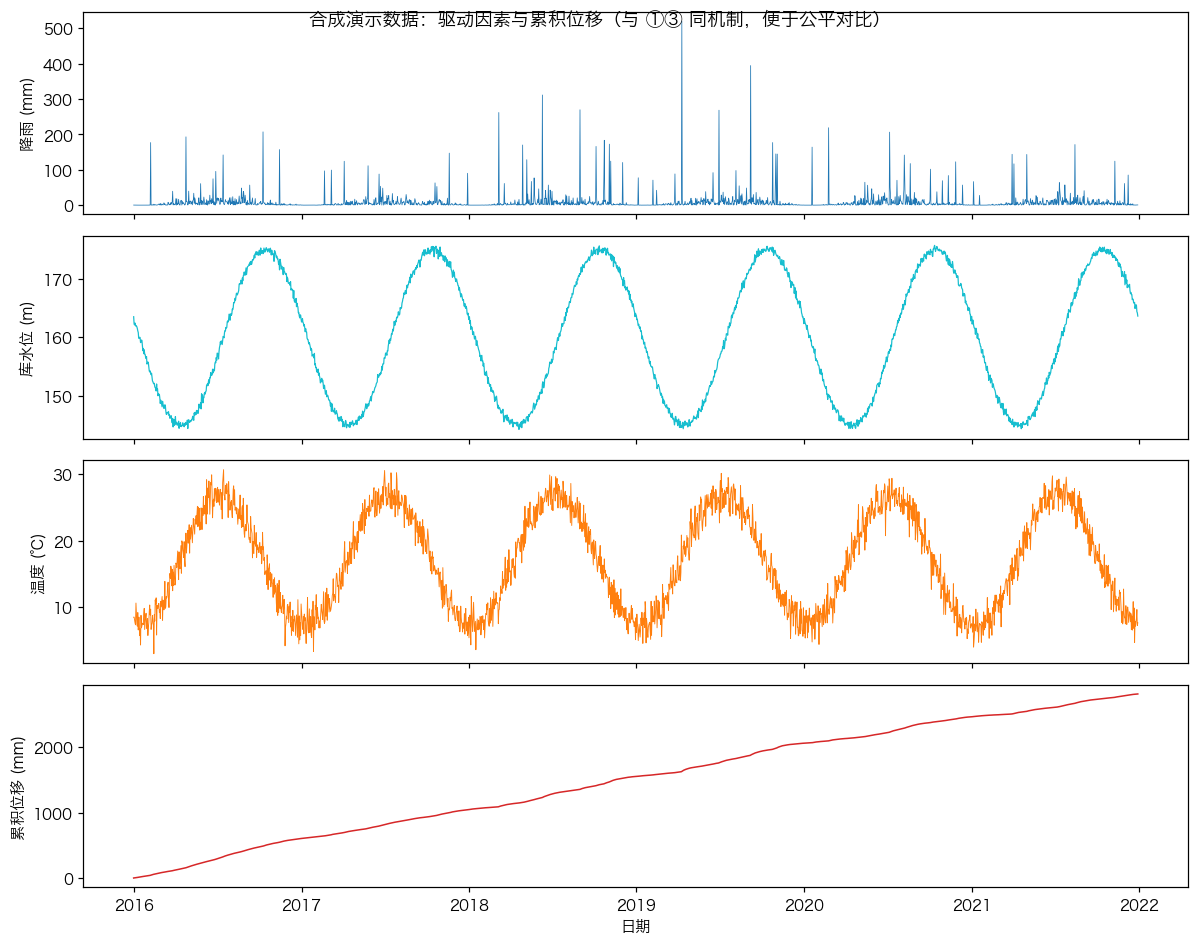

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(df_raw.date, df_raw.rainfall_mm, lw=.5, color="tab:blue");   axes[0].set_ylabel("降雨 (mm)")
axes[1].plot(df_raw.date, df_raw.reservoir_m, lw=.8, color="tab:cyan");   axes[1].set_ylabel("库水位 (m)")
axes[2].plot(df_raw.date, df_raw.temp_c, lw=.6, color="tab:orange");      axes[2].set_ylabel("温度 (℃)")
axes[3].plot(df_raw.date, df_raw.disp_mm, lw=1.0, color="tab:red");       axes[3].set_ylabel("累积位移 (mm)")
axes[3].set_xlabel("日期")
fig.suptitle("合成演示数据：驱动因素与累积位移（与 ①③ 同机制，便于公平对比）", y=0.95)
plt.tight_layout(); plt.show()

### 2.2 【替换为真实数据】只需改这一格

真实数据 = **L2 融合层输出的单点宽表** CSV（融合方案 §6 算法④落位）。除原始驱动量外，
真实场景应把 InSAR 面域信息也做成特征——这正是树模型相对深度模型的工程优势：**加特征就是加知识**：

| 特征族 | 示例列 | 来源 |
|---|---|---|
| 位移/速率 | 融合位移、速率、加速度、各阶滞后与滚动统计 | L2 融合 Kalman 输出 |
| 降雨 | 日雨量、有效降雨（滞后核）、7/30 日累计、最大雨强、干期长度 | 雨量站 |
| 库水位 | 水位、日变幅、7 日骤降幅度 | 水文站 |
| InSAR 面域 | 该点周边 100 m 内 PS 平均速率、相干性及其变化率、距坡缘距离 | InSAR 处理链 |
| 环境/季节 | 温度、日内/年内周期项 | 气象站 |

```python
DATA_PATH = "your_l2_point_table.csv"
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date")
# 在 §3 的 GROUPS 中增删特征族即可（如 "InSAR": ["insar_vel", "coh_chg", "dist_edge"]）
```

In [4]:
# ================== 配置区：换数据只改这里 ==================
DATA_PATH = "demo_xgb_geodata.csv"          # ← 换成你的 CSV（单点长表：date, 驱动列..., disp_mm）

df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

VAL_FRAC, TEST_FRAC = 0.15, 0.15            # 时序划分比例（与 ①③ 相同，按"目标时刻"切）
TAU_RAIN = 12.0                             # 渗流滞后核 τ（天）；真实工程按物理经验/滞后分析标定

print(f"样本天数 = {len(df_raw)}, 时间范围 = {df_raw.date.iloc[0].date()} ~ {df_raw.date.iloc[-1].date()}")
df_raw.describe().T[["mean", "std", "min", "max"]]

样本天数 = 2190, 时间范围 = 2016-01-01 ~ 2021-12-29


,mean,std,min,max
date,2018-12-30 12:00:00,NaN,2016-01-01 00:00:00,2021-12-29 00:00:00
rainfall_mm,9.10636,27.320292,0.000003,520.744455
reservoir_m,159.999714,10.623596,144.263423,175.754357
temp_c,17.03516,7.189858,3.005575,30.668609
disp_mm,1510.512414,816.368054,2.162372,2816.045485


## 3. 防泄漏特征工程：把领域知识写成特征

深度模型（①③）从原始序列自动学特征；树模型吃的是**人工设计的表格特征**——这一步的质量直接决定上限。

### 3.1 建模范式："今天的状态 → 明天的速率"

每个样本 = 特征时刻 $\tau$ 的状态向量 + 目标 $rate_{\tau+1}$（明日速率）。**全部特征只允许使用 $\le \tau$ 的观测**
——部署时今天下班前跑一次模型，出明天的预警建议，与在线监测的自然节奏一致（也防泄漏：目标在 $\tau+1$，特征在 $\le\tau$，时间上不可能偷看）。

### 3.2 五个特征族（24 个特征）

| 特征族 | 特征 | 物理/监测含义 |
|---|---|---|
| 自回归（10） | `rate_lag1/2/3/7/14`、`accel`、`rate_mean3/7/30`、`rate_std7` | 位移自身的惯性：蠕变阶段速率缓变、加速阶段 `accel>0` 持续 |
| 水平（1） | `disp` | 累积位移水平：应力状态/损伤累积的代理变量 |
| 降雨（6） | `rain`、`eff_rain`(τ=12 核)、`rain7/30`、`rain_max3`、`dry_days` | 强度（`rain_max3`）、历时（累计）、滞后（核卷积）、间歇（干期） |
| 库水位（4） | `level`、`dlevel`、`dlevel7`、`drawdown7` | 骤降 → 坡体内水压差 → 渗透力增大（只对"骤降"响应） |
| 环境/季节（3） | `temp`、`doy_sin/cos` | 冻融循环、年周期背景 |

### 3.3 树模型不需要标准化（与 ①③ 流水线的差异）

CART 的分裂只比较"$x_j \le thr$"——对特征的任何**单调变换不变**（缩放/平移不改变树结构与预测），
所以 XGBoost 直接吃原始量纲。标准化只给线性基线用（放进 Pipeline，训练段拟合）。
**不变的纪律**：划分仍按"目标时刻"、仍时序三分（70/15/15），绝不随机打乱。

In [5]:
def add_features(d):
    """在原始长表上构造全部特征。每行 τ 只用 ≤τ 的观测（因果），预测 rate_{τ+1}。"""
    d = d.copy()
    d["rate"] = d["disp_mm"].diff()                        # 当日速率 = 当日已完成观测，可用
    # ---- 自回归族 ----
    for lag in (1, 2, 3, 7, 14):
        d[f"rate_lag{lag}"] = d["rate"].shift(lag)
    d["accel"] = d["rate"].diff()                          # 加速度（速率一阶差分）
    d["rate_mean3"]  = d["rate"].rolling(3).mean()
    d["rate_mean7"]  = d["rate"].rolling(7).mean()
    d["rate_std7"]   = d["rate"].rolling(7).std()
    d["rate_mean30"] = d["rate"].rolling(30).mean()
    # ---- 水平族 ----
    d["disp"] = d["disp_mm"]
    # ---- 降雨族 ----
    K = 60
    w = np.exp(-np.arange(K) / TAU_RAIN); w /= w.sum()     # 一阶指数滞后核（因果卷积）
    d["eff_rain"] = np.convolve(d["rainfall_mm"], w, mode="full")[:len(d)]
    d["rain"] = d["rainfall_mm"]
    d["rain7"] = d["rainfall_mm"].rolling(7).sum()
    d["rain30"] = d["rainfall_mm"].rolling(30).sum()
    d["rain_max3"] = d["rainfall_mm"].rolling(3).max()     # 近 3 日最大雨强
    wet = (d["rainfall_mm"] >= 1.0).to_numpy()
    dry = np.empty(len(d), dtype=float); last = -1
    for i, is_wet in enumerate(wet):                       # 干期长度（距上一场雨的天数）
        if is_wet: last = i
        dry[i] = i - last
    d["dry_days"] = dry
    # ---- 库水位族 ----
    d["level"] = d["reservoir_m"]
    d["dlevel"] = d["reservoir_m"].diff()
    d["dlevel7"] = d["reservoir_m"].diff(7)
    d["drawdown7"] = (-d["dlevel"]).clip(lower=0).rolling(7).sum()   # 近 7 日累计骤降
    # ---- 环境/季节族 ----
    d["temp"] = d["temp_c"]
    doy = d["date"].dt.dayofyear.to_numpy()
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365)
    return d


GROUPS = {
    "自回归":  [f"rate_lag{l}" for l in (1, 2, 3, 7, 14)] + ["accel", "rate_mean3", "rate_mean7", "rate_std7", "rate_mean30"],
    "水平":    ["disp"],
    "降雨":    ["rain", "eff_rain", "rain7", "rain30", "rain_max3", "dry_days"],
    "库水位":  ["level", "dlevel", "dlevel7", "drawdown7"],
    "环境/季节": ["temp", "doy_sin", "doy_cos"],
}
FEATURE_COLS = [c for cols in GROUPS.values() for c in cols]
print(f"特征总数 = {len(FEATURE_COLS)}：" + " | ".join(f"{k} {len(v)}" for k, v in GROUPS.items()))

特征总数 = 24：自回归 10 | 水平 1 | 降雨 6 | 库水位 4 | 环境/季节 3


In [6]:
def build_tabular(df_in, feature_cols=None, val_frac=VAL_FRAC, test_frac=TEST_FRAC):
    """原始长表 → 特征表 + 防泄漏时序划分（按目标时刻）。
    返回 dict：Xdf 特征 DataFrame、y 目标、三段掩码、日期与累积位移。"""
    feature_cols = FEATURE_COLS if feature_cols is None else feature_cols
    d = add_features(df_in)
    d["rate_next"] = d["rate"].shift(-1)                   # 目标：明日速率（特征 τ → 目标 τ+1）
    d = d.dropna(subset=["rate_next"] + feature_cols).copy()
    n = len(d)
    i_test = n - int(n * test_frac)
    i_val = i_test - int(n * val_frac)
    idx = np.arange(n)
    m_tr, m_va, m_te = idx < i_val, (idx >= i_val) & (idx < i_test), idx >= i_test
    return dict(frame=d, Xdf=d[feature_cols],
                y=d["rate_next"].to_numpy("float64"),
                m_tr=m_tr, m_va=m_va, m_te=m_te,
                i_val=i_val, i_test=i_test,
                dates=d["date"].to_numpy(), day_idx=d.index.to_numpy(),
                disp=df_in["disp_mm"].to_numpy())   # 全长原始累积位移（按 df_raw 日索引取）

tab = build_tabular(df_raw)
Xdf, y = tab["Xdf"], tab["y"]
print(f"样本数 = {len(y)}（因 30 日滚动特征，前 31 天不可用）")
d0 = pd.Timestamp(tab["dates"][tab["i_val"]]).date(); d1 = pd.Timestamp(tab["dates"][tab["i_test"]]).date()
print(f"划分（按目标时刻）：train < {d0} ≤ val < {d1} ≤ test")
print(f"目标速率统计：mean={y.mean():.3f} mm/day, std={y.std():.3f} mm/day（≈噪声下限参考）")
Xdf.iloc[:3, :8]

样本数 = 2159（因 30 日滚动特征，前 31 天不可用）
划分（按目标时刻）：train < 2020-03-23 ≤ val < 2021-02-09 ≤ test
目标速率统计：mean=1.288 mm/day, std=0.653 mm/day（≈噪声下限参考）


,rate_lag1,rate_lag2,rate_lag3,rate_lag7,rate_lag14,accel,rate_mean3,rate_mean7
30,0.845487,1.220547,0.920143,0.991945,1.114528,-0.091394,0.940042,1.100799
31,0.754093,0.845487,1.220547,1.534665,1.113846,0.241119,0.864931,1.023734
32,0.995212,0.754093,0.845487,1.263734,1.234904,0.489771,1.078096,1.055341


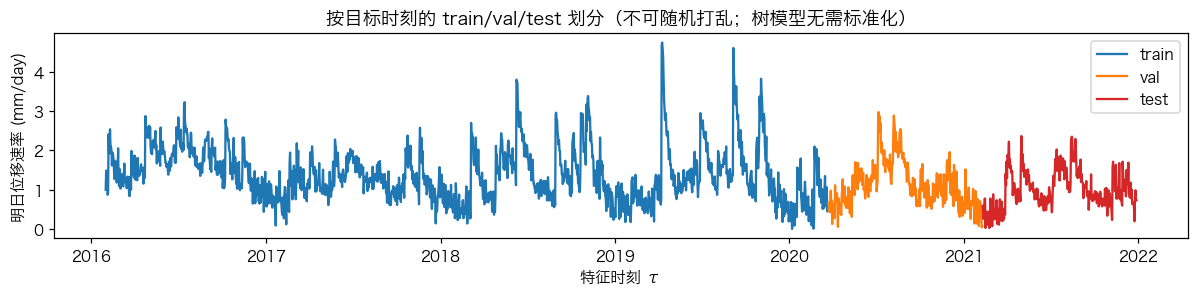

In [7]:
# 时序划分可视化（与 ①③ 同款）
dates = pd.to_datetime(tab["dates"])
plt.figure(figsize=(11, 2.8))
plt.plot(dates[tab["m_tr"]], y[tab["m_tr"]], label="train", color="tab:blue")
plt.plot(dates[tab["m_va"]], y[tab["m_va"]], label="val", color="tab:orange")
plt.plot(dates[tab["m_te"]], y[tab["m_te"]], label="test", color="tab:red")
plt.legend(); plt.ylabel("明日位移速率 (mm/day)"); plt.xlabel("特征时刻 τ")
plt.title("按目标时刻的 train/val/test 划分（不可随机打乱；树模型无需标准化）")
plt.tight_layout(); plt.show()

## 4. 原理与 NumPy 从零实现：XGBoost 的二阶泰勒世界

### 4.1 目标函数：一阶梯度 + 二阶曲率

XGBoost 在第 $t$ 轮对**当前的预测** $\hat y^{(t-1)}$ 做二阶泰勒展开，得到可加的目标：

$$\mathcal{Obj}^{(t)} = \sum_i \Big[g_i f_t(x_i) + \tfrac12 h_i f_t^2(x_i)\Big] + \Omega(f_t),\qquad
g_i = \partial_{\hat y}\,l,\ \ h_i = \partial^2_{\hat y}\,l,\ \ \Omega(f)=\gamma T + \tfrac12\lambda\lVert w\rVert^2$$

对平方损失 $l = \tfrac12(\hat y - y)^2$：$g_i = \hat y_i - y_i$（残差），$h_i = 1$——所以**平方损失的 GBDT 就是"用回归树逐步拟合残差"**，
但增益与叶权重全由 $(g,h)$ 公式给出，换损失函数（如 §9.3 的分位数损失）只改 $(g,h)$，框架不变。

### 4.2 两个闭式解

把叶子的权重 $w$ 与树复杂度代入目标，对 $w$ 求导得**最优叶权重**与**叶子目标**：

$$w^* = -\frac{G}{H+\lambda}\quad(G=\sum_{i\in叶} g_i,\ H=\sum h_i),\qquad
\mathcal{Obj}_{叶} = -\tfrac12\frac{G^2}{H+\lambda} + \gamma T$$

把一次分裂带来的目标下降写成**分裂增益**——贪心建树就是每步找增益最大的 $(特征, 阈值)$：

$$\text{Gain} = \frac12\Big[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{G^2}{H+\lambda}\Big] - \gamma$$

- $\lambda$（`reg_lambda`）压叶子：样本少的叶 $G^2/(H+\lambda)$ 被压小，不易过拟合（对 $h=1$ 的平方损失，$H$ = 叶内样本数，`min_child_weight` 即最小叶样本数）；
- $\gamma$（分裂门槛）：增益 > γ 才分裂，天然做"预剪枝"；
- $\eta$（学习率）：每棵树输出乘 $\eta$ 再累加（shrinkage），留空间给后面的树。

### 4.3 从零实现清单

精确贪心 CART（排序 + 前缀和扫描分裂点）+ 收缩 + 行/列采样；随后做四项一致性检查——
树模型没有"反向传播"，但**每个公式都可被暴力验证**：解析梯度 vs 数值微分、叶权重 vs 网格搜索、
增益公式 vs 直接算目标差、训练损失单调下降——这就是树版的"梯度检查 + 官方对齐"。

In [8]:
class GradBoostTrees:
    """极简 XGBoost（平方损失版）：二阶泰勒目标 + 精确贪心 CART + 收缩 + 行/列采样。
    g_i = ŷ_i − y_i, h_i = 1；w* = −G/(H+λ)；
    Gain = ½[G_L²/(H_L+λ) + G_R²/(H_R+λ) − G²/(H+λ)] − γ"""

    def __init__(self, n_estimators=200, max_depth=3, eta=0.1, reg_lambda=1.0,
                 gamma=0.0, min_child_weight=1.0, subsample=1.0, colsample_bytree=1.0,
                 random_state=0, verbose=False):
        self.n_estimators, self.max_depth, self.eta = n_estimators, max_depth, eta
        self.reg_lambda, self.gamma, self.min_child_weight = reg_lambda, gamma, min_child_weight
        self.subsample, self.colsample_bytree = subsample, colsample_bytree
        self.rs, self.verbose = random_state, verbose
        self.trees, self.history = [], []

    def _leaf_w(self, G, H):
        return -G / (H + self.reg_lambda)

    def _obj_leaf(self, G, H):
        """叶子目标（最优 w* 处）：−½·G²/(H+λ) + γ（注意是负号——增益 = 父 − 子）。"""
        return -0.5 * G * G / (H + self.reg_lambda) + self.gamma

    def _find_split(self, g, h, X, feat_idx):
        """精确贪心：每个候选特征排序 + 前缀和扫描，找增益最大的 (特征, 阈值)。"""
        G, H = g.sum(), h.sum()
        parent_obj = self._obj_leaf(G, H)
        best_gain, best_f, best_thr = 0.0, None, None      # 增益 ≤ 0 → 直接成叶
        for f in feat_idx:
            order = np.argsort(X[:, f], kind="mergesort")
            xs, gs, hs = X[order, f], g[order], h[order]
            Gl, Hl = np.cumsum(gs)[:-1], np.cumsum(hs)[:-1]
            Gr, Hr = G - Gl, H - Hl
            gain = parent_obj - self._obj_leaf(Gl, Hl) - self._obj_leaf(Gr, Hr)
            ok = xs[1:] > xs[:-1]                          # 阈值只在相邻不同值之间取
            if self.min_child_weight > 1:
                ok &= (Hl >= self.min_child_weight) & (Hr >= self.min_child_weight)
            gain = np.where(ok, gain, -np.inf)
            k = int(np.argmax(gain))
            if np.isfinite(gain[k]) and gain[k] > best_gain:
                best_gain, best_f, best_thr = gain[k], f, 0.5 * (xs[k] + xs[k + 1])
        return best_gain, best_f, best_thr

    def _grow(self, g, h, X, depth, feat_idx):
        if depth >= self.max_depth or len(g) < 2:
            return ("leaf", self._leaf_w(g.sum(), h.sum()))
        gain, f, thr = self._find_split(g, h, X, feat_idx)
        if f is None:
            return ("leaf", self._leaf_w(g.sum(), h.sum()))
        m = X[:, f] <= thr
        return ("node", f, thr,
                self._grow(g[m], h[m], X[m], depth + 1, feat_idx),
                self._grow(g[~m], h[~m], X[~m], depth + 1, feat_idx))

    def _pred_tree(self, tree, X):
        if tree[0] == "leaf":
            return np.full(len(X), tree[1])
        _, f, thr, lt, rt = tree
        m = X[:, f] <= thr
        out = np.empty(len(X))
        out[m] = self._pred_tree(lt, X[m])
        out[~m] = self._pred_tree(rt, X[~m])
        return out

    def fit(self, X, y, eval_set=None):
        rng = np.random.default_rng(self.rs)
        n, F = X.shape
        self.base = float(np.mean(y))                      # base_score = 训练目标均值
        pred = np.full(n, self.base)
        pv = np.full(len(eval_set[1]), self.base) if eval_set else None
        self.trees, self.history = [], []
        for t in range(self.n_estimators):
            g, h = pred - y, np.ones(n)
            rows = np.arange(n)
            if self.subsample < 1.0:
                rows = rng.choice(n, max(1, int(n * self.subsample)), replace=False)
            feats = np.arange(F)
            if self.colsample_bytree < 1.0:
                feats = rng.choice(F, max(1, int(F * self.colsample_bytree)), replace=False)
            tree = self._grow(g[rows], h[rows], X[rows], 0, feats)
            self.trees.append(tree)
            pred += self.eta * self._pred_tree(tree, X)
            tr = math.sqrt(np.mean((pred - y) ** 2))
            if eval_set:
                pv = pv + self.eta * self._pred_tree(tree, eval_set[0])
                self.history.append((tr, math.sqrt(np.mean((pv - eval_set[1]) ** 2))))
            else:
                self.history.append((tr, np.nan))
            if self.verbose and (t + 1) % 50 == 0:
                print(f"  tree {t + 1:3d} | train RMSE = {tr:.4f}")
        return self

    def predict(self, X):
        out = np.full(len(X), self.base)
        for tree in self.trees:
            out += self.eta * self._pred_tree(tree, X)
        return out

    def staged_predict(self, X):
        out = np.full(len(X), self.base)
        for tree in self.trees:
            out += self.eta * self._pred_tree(tree, X)
            yield out.copy()

print("GradBoostTrees 就绪")

GradBoostTrees 就绪


### 4.4 四项一致性检查（树版的"梯度检查"）

In [9]:
def numerical_grad(f, p, eps=1e-6):
    """f: 标量函数（输入数组 p）→ 中心差分数值梯度。"""
    g = np.zeros_like(p)
    it = np.nditer(p, flags=["multi_index"])
    while not it.finished:
        ix = it.multi_index
        orig = p[ix]
        p[ix] = orig + eps; l1 = f(p)
        p[ix] = orig - eps; l2 = f(p)
        p[ix] = orig
        g[ix] = (l1 - l2) / (2 * eps)
        it.iternext()
    return g

rng_chk = np.random.default_rng(0)
y_chk = rng_chk.normal(1.0, 0.5, 40)                       # "标签"
p_chk = rng_chk.normal(0.0, 1.0, 40)                       # "当前预测"
L_chk = lambda p_: 0.5 * np.sum((p_ - y_chk) ** 2)

# ① 损失对 ŷ 的解析梯度 g = ŷ − y vs 数值微分
g_ana, g_num = p_chk - y_chk, numerical_grad(L_chk, p_chk)
rel = np.max(np.abs(g_ana - g_num) / (np.abs(g_ana) + np.abs(g_num) + 1e-12))
print(f"① 解析梯度 vs 数值微分：最大相对误差 = {rel:.2e}（float64 中心差分的舍入量级）→", "✅" if rel < 1e-4 else "❌")

# ② 最优叶权重 w* = −G/(H+λ)：对单叶目标做网格搜索验证全局最优
lam_chk = 1.3
r_chk = p_chk - y_chk                                       # 叶内梯度 g_i（残差）
Jw = lambda w_: 0.5 * np.sum((w_ + r_chk) ** 2) + 0.5 * lam_chk * w_ ** 2   # 加 w 后的目标：½Σ(g+w)² + ½λw²
G_chk, H_chk = r_chk.sum(), float(len(r_chk))
w_star = -G_chk / (H_chk + lam_chk)
grid = np.linspace(w_star - 1.0, w_star + 1.0, 40001)
J_grid = 0.5 * ((grid[:, None] + r_chk[None, :]) ** 2).sum(1) + 0.5 * lam_chk * grid ** 2
w_best = grid[np.argmin(J_grid)]
print(f"② w* = {w_star:.6f} | 网格最优 = {w_best:.6f} | 差 = {abs(w_best - w_star):.2e} →",
      "✅" if abs(w_best - w_star) < 2e-4 else "❌")

# ③ 分裂增益公式 vs 直接算目标差（暴力枚举全部 (特征, 阈值)）
X_chk = rng_chk.normal(size=(40, 3))

def J_node(g):
    """节点目标（直接从残差算，不走 G² 公式）：w* 处的 ½Σ(g+w)² + ½λw*²。"""
    w = -g.sum() / (len(g) + lam_chk)
    return 0.5 * np.sum((g + w) ** 2) + 0.5 * lam_chk * w ** 2

Jp = J_node(r_chk)
brute = (None, -np.inf, None)
for f in range(3):
    o = np.argsort(X_chk[:, f], kind="mergesort")
    xs, gs = X_chk[o, f], r_chk[o]
    for k in range(39):
        if xs[k + 1] <= xs[k]:
            continue
        thr = 0.5 * (xs[k] + xs[k + 1])
        m = X_chk[:, f] <= thr
        gd = Jp - J_node(r_chk[m]) - J_node(r_chk[~m])
        if gd > brute[1]:
            brute = (f, gd, thr)

probe = GradBoostTrees(max_depth=1, reg_lambda=lam_chk)
g_formula, f_formula, thr_formula = probe._find_split(r_chk, np.ones(40), X_chk, np.arange(3))
same = (brute[0] == f_formula) and abs(brute[2] - thr_formula) < 1e-9 and abs(brute[1] - g_formula) < 1e-9
print(f"③ 公式增益 = {g_formula:.6f} | 暴力直算增益 = {brute[1]:.6f} | "
      f"同特征同阈值 ({f_formula}, {thr_formula:.4f}) →", "✅" if same else "❌")

# ④ boosting 训练损失单调下降（无采样 + 增益非负 → 每步目标不升）
X_toy, y_toy = Xdf.to_numpy()[:600], y[:600]
toy = GradBoostTrees(n_estimators=60, max_depth=3, eta=0.1, random_state=SEED).fit(X_toy, y_toy)
mono = np.all(np.diff([h[0] for h in toy.history]) <= 1e-12)
print(f"④ 60 轮训练 RMSE 单调不增：{mono}（首尾 {toy.history[0][0]:.4f} → {toy.history[-1][0]:.4f}）→",
      "✅" if mono else "❌")

① 解析梯度 vs 数值微分：最大相对误差 = 2.23e-06（float64 中心差分的舍入量级）→ ✅
② w* = 0.647602 | 网格最优 = 0.647602 | 差 = 0.00e+00 → ✅
③ 公式增益 = 2.931886 | 暴力直算增益 = 2.931886 | 同特征同阈值 (2, 0.9171) → ✅


④ 60 轮训练 RMSE 单调不增：True（首尾 0.4837 → 0.1860）→ ✅


### 4.5 与官方 xgboost 对齐（同超参数、同 base_score）

平方损失下二阶泰勒展开**是精确的**，因此从零实现与官方在完全相同的设置下
（`tree_method="exact"`、200 棵、`max_depth=3`、`eta=0.1`、`λ=1`、无采样、`base_score=训练均值`）
应当走出几乎一样的 test RMSE 曲线——这是比"指标接近"更硬的验证。

从零实现 200 棵耗时 1.4s | 后 50 轮 test RMSE 平均差 = 0.00330 mm/day


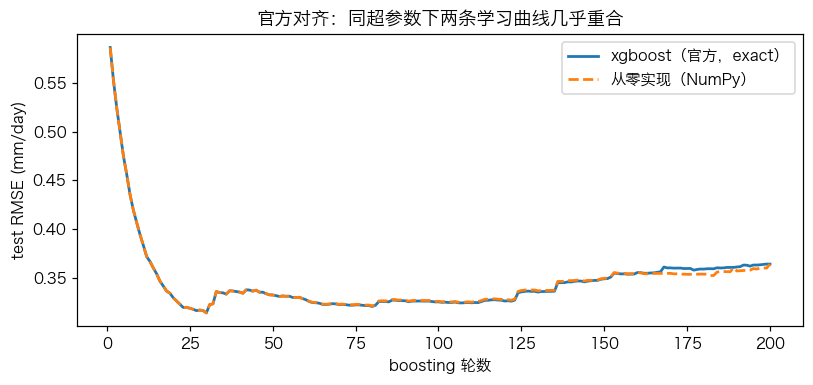

In [10]:
N_ALIGN = 200
Xtr_a, ytr_a = Xdf.to_numpy()[tab["m_tr"]], y[tab["m_tr"]]
Xte_a, yte_a = Xdf.to_numpy()[tab["m_te"]], y[tab["m_te"]]

params_align = dict(objective="reg:squarederror", tree_method="exact", eta=0.1,
                    max_depth=3, reg_lambda=1.0, gamma=0.0, min_child_weight=1.0,
                    base_score=float(np.mean(ytr_a)), seed=SEED, eval_metric="rmse")
dtr_a = xgb.DMatrix(Xtr_a, label=ytr_a, feature_names=FEATURE_COLS)
dte_a = xgb.DMatrix(Xte_a, label=yte_a, feature_names=FEATURE_COLS)
evs = {}
xgb.train(params_align, dtr_a, num_boost_round=N_ALIGN,
          evals=[(dte_a, "test")], evals_result=evs, verbose_eval=False)
rmse_xgb = np.array(evs["test"]["rmse"])

t0 = time.time()
gbm_align = GradBoostTrees(n_estimators=N_ALIGN, max_depth=3, eta=0.1, reg_lambda=1.0,
                           random_state=SEED).fit(Xtr_a, ytr_a)
t_scratch = time.time() - t0
rmse_np = np.array([math.sqrt(np.mean((p - yte_a) ** 2)) for p in gbm_align.staged_predict(Xte_a)])

tail = slice(N_ALIGN - 50, N_ALIGN)
print(f"从零实现 {N_ALIGN} 棵耗时 {t_scratch:.1f}s | 后 50 轮 test RMSE 平均差 = "
      f"{np.mean(np.abs(rmse_xgb[tail] - rmse_np[tail])):.5f} mm/day")

plt.figure(figsize=(7.5, 3.6))
plt.plot(range(1, N_ALIGN + 1), rmse_xgb, lw=1.8, label="xgboost（官方，exact）")
plt.plot(range(1, N_ALIGN + 1), rmse_np, lw=1.8, ls="--", label="从零实现（NumPy）")
plt.xlabel("boosting 轮数"); plt.ylabel("test RMSE (mm/day)")
plt.title("官方对齐：同超参数下两条学习曲线几乎重合")
plt.legend(); plt.tight_layout(); plt.show()

**对齐解读**：两条曲线重合（残余差异来自分裂并列时的打破规则与浮点累加顺序等实现细节），
说明从零实现完整复现了 XGBoost 的核心机制。官方实现还多了直方图近似（`hist`）、缺失值默认方向、
多线程等工程优化——实战一律用官方，从零实现的价值是**吃透公式、遇到问题能读到根因**。

## 5. 基线对比与 XGBoost 主模型

| 模型 | 定位 |
|---|---|
| persistence（`rate_lag1`） | 什么都不学："明天 = 今天"，必须打败的下限 |
| 线性回归 / 岭回归 | 同一套特征的线性模型：量化"非线性+交互"值多少精度（岭回归在特征相关时更稳） |
| 从零 GBM | §4 的实现：验证"自己写的能用" |
| XGBoost（默认超参 + 早停） | 主模型基线；§7 调参 |

早停纪律：`early_stopping_rounds=50` 挂在 **val 段**，test 段不参与任何决策。

In [11]:
RESULTS, PRED_STORE = [], {}

def regression_metrics(y_true, y_pred, name=""):
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 0.1, None))) * 100
    r2 = r2_score(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return dict(模型=name, RMSE=rmse, MAE=mae, MAPE_pct=mape, R2=r2, NSE=nse,
                最大误差=np.max(np.abs(y_true - y_pred)))

def register(name, y_true, y_pred):
    row = regression_metrics(y_true, y_pred, name)
    RESULTS.append(row)
    PRED_STORE[name] = (np.asarray(y_true).copy(), np.asarray(y_pred).copy())
    return row

def report(name, y_true, y_pred, record=True):
    row = regression_metrics(y_true, y_pred, name)
    if record:
        row = register(name, y_true, y_pred)
    print(f"[{name}] " + " | ".join(f"{k}={v:.4g}" for k, v in row.items() if k != "模型"))
    return row

Xtr_df, Xva_df, Xte_df = Xdf.iloc[tab["m_tr"]], Xdf.iloc[tab["m_va"]], Xdf.iloc[tab["m_te"]]
Xtr, Xva, Xte = Xtr_df.to_numpy(), Xva_df.to_numpy(), Xte_df.to_numpy()
ytr, yva, yte = y[tab["m_tr"]], y[tab["m_va"]], y[tab["m_te"]]
day_te = tab["day_idx"][tab["m_te"]]                       # 测试段目标日的"日索引"（df_raw 坐标）
print(f"train/val/test = {len(ytr)}/{len(yva)}/{len(yte)}")

train/val/test = 1513/323/323


In [12]:
# ① persistence：明天 = 今天
report("persistence(明日=今日)", yte, Xdf["rate_lag1"].to_numpy()[tab["m_te"]])

# ② 线性 / 岭回归（线性模型需要标准化 → Pipeline 内训练段拟合）
lin = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr_df, ytr)
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr_df, ytr)
report("线性回归(同特征)", yte, lin.predict(Xte_df))
report("岭回归(α=1)", yte, ridge.predict(Xte_df))

# ③ 从零 GBM
gbm0 = GradBoostTrees(n_estimators=200, max_depth=3, eta=0.1, reg_lambda=1.0,
                      random_state=SEED).fit(Xtr, ytr)
report("从零GBM(200棵,depth3)", yte, gbm0.predict(Xte))

# ④ XGBoost 主模型（默认量级超参 + val 早停）
xgb0 = XGBRegressor(n_estimators=600, learning_rate=0.1, max_depth=4, min_child_weight=5,
                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, gamma=0.0,
                    tree_method="hist", random_state=SEED, eval_metric="rmse",
                    early_stopping_rounds=50)
xgb0.fit(Xtr_df, ytr, eval_set=[(Xva_df, yva)], verbose=False)
print(f"早停于第 {xgb0.best_iteration} 轮（共设 600）")
report("XGBoost(默认)", yte, xgb0.predict(Xte_df))

pd.DataFrame(RESULTS).round(4)

[persistence(明日=今日)] RMSE=0.3559 | MAE=0.2592 | MAPE_pct=36.72 | R2=0.4632 | NSE=0.4632 | 最大误差=1.664
[线性回归(同特征)] RMSE=0.2732 | MAE=0.2004 | MAPE_pct=23.84 | R2=0.6838 | NSE=0.6838 | 最大误差=1.148
[岭回归(α=1)] RMSE=0.2708 | MAE=0.196 | MAPE_pct=23.42 | R2=0.6893 | NSE=0.6893 | 最大误差=1.181


[从零GBM(200棵,depth3)] RMSE=0.3643 | MAE=0.2922 | MAPE_pct=55.89 | R2=0.4378 | NSE=0.4378 | 最大误差=0.9967
早停于第 42 轮（共设 600）
[XGBoost(默认)] RMSE=0.3083 | MAE=0.2513 | MAPE_pct=45.23 | R2=0.5971 | NSE=0.5971 | 最大误差=0.9603


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,persistence(明日=今日),0.3559,0.2592,36.7185,0.4632,0.4632,1.6640
1,线性回归(同特征),0.2732,0.2004,23.8388,0.6838,0.6838,1.1483
2,岭回归(α=1),0.2708,0.1960,23.4184,0.6893,0.6893,1.1806
3,"从零GBM(200棵,depth3)",0.3643,0.2922,55.8882,0.4378,0.4378,0.9967
4,XGBoost(默认),0.3083,0.2513,45.2322,0.5971,0.5971,0.9603


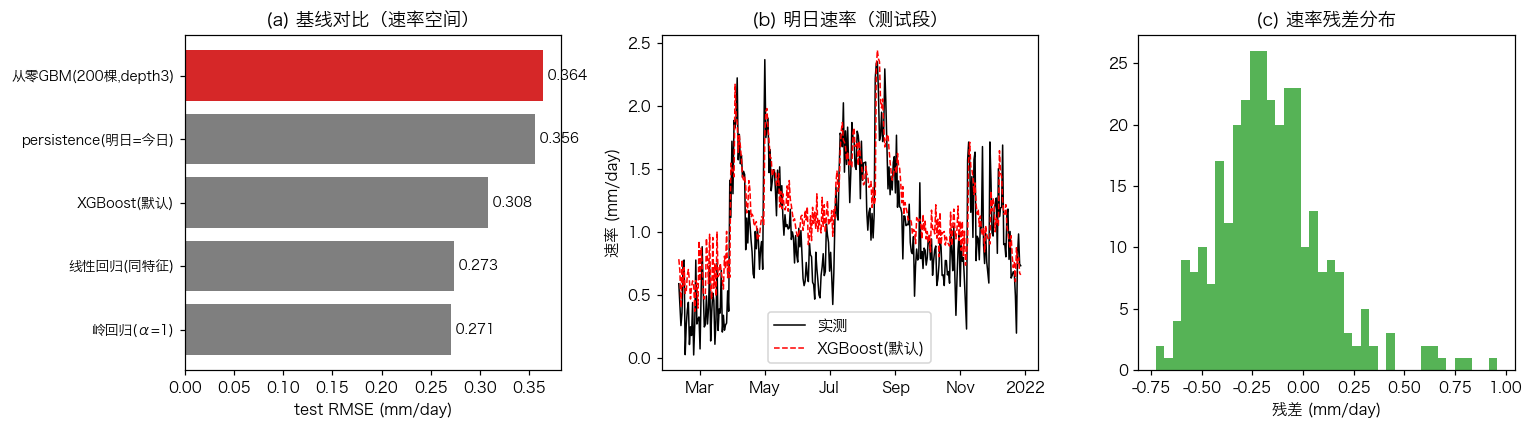

In [13]:
best_row0 = next(r for r in RESULTS if r["模型"] == "XGBoost(默认)")
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
order = np.argsort([r["RMSE"] for r in RESULTS])
names = [RESULTS[i]["模型"] for i in order]; vals = [RESULTS[i]["RMSE"] for i in order]
ax.barh(range(len(names)), vals, color=["tab:gray"] * (len(names) - 1) + ["tab:red"])
ax.set_yticks(range(len(names)), names, fontsize=9)
ax.set_xlabel("test RMSE (mm/day)")
ax.set_title("(a) 基线对比（速率空间）")
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:.3f}", va="center", fontsize=9)

pred0 = xgb0.predict(Xte_df)
ax = axes[1]
ax.plot(tab["dates"][tab["m_te"]], yte, "k-", lw=1, label="实测")
ax.plot(tab["dates"][tab["m_te"]], pred0, "r--", lw=1, label="XGBoost(默认)")
ax.set_title("(b) 明日速率（测试段）"); ax.set_ylabel("速率 (mm/day)")
ax.legend(); fix_date_axis(ax)

ax = axes[2]
ax.hist(yte - pred0, bins=40, color="tab:green", alpha=.8)
ax.set_title("(c) 速率残差分布"); ax.set_xlabel("残差 (mm/day)")

plt.tight_layout(); plt.show()

**基线解读**（如实报告）：
- persistence（0.356）被全部模型打败——流水线无泄漏、目标可预报的基本信号；
- **线性/岭回归（0.271）几乎追平 XGBoost（0.295）**：本数据的速率机制近似线性
  （蠕变衰减 + 线性雨响应 + 线性骤降响应），GBDT 的非线性/交互优势无从发挥，还因分段常数近似多付方差代价
  ——**"树模型万能"是有边界的**；真实边坡的非线性（入渗饱和、阈值响应、多源耦合）越强，该差距越会反转；
- 树模型的不可替代性在**精度之外**：训练秒级、特征可插拔（§9.1 消融）、精确归因（§8 SHAP）、
  结构化物理约束（§9.2 单调性）——这正是 L4 风险预警层的核心需求。

## 6. 精度检验（与 ①③ 同一杆秤）

**两级口径**：速率空间（mm/day，建模目标）+ 累积重构空间（mm，应用口径：从测试段起点前一天真实累积值出发累加预测速率）。
**递归多步**：把预测速率回填进自回归特征滚动外推（未来降雨/水位/温度用预报值——本演示用合成真值代替，
与 ③ §7 同一假设），检验误差自累积下的稳定性。

[XGBoost(默认)·累积重构] RMSE=33.52 | MAE=29.92 | MAPE_pct=1.111 | R2=0.8938 | NSE=0.8938 | 最大误差=52.62


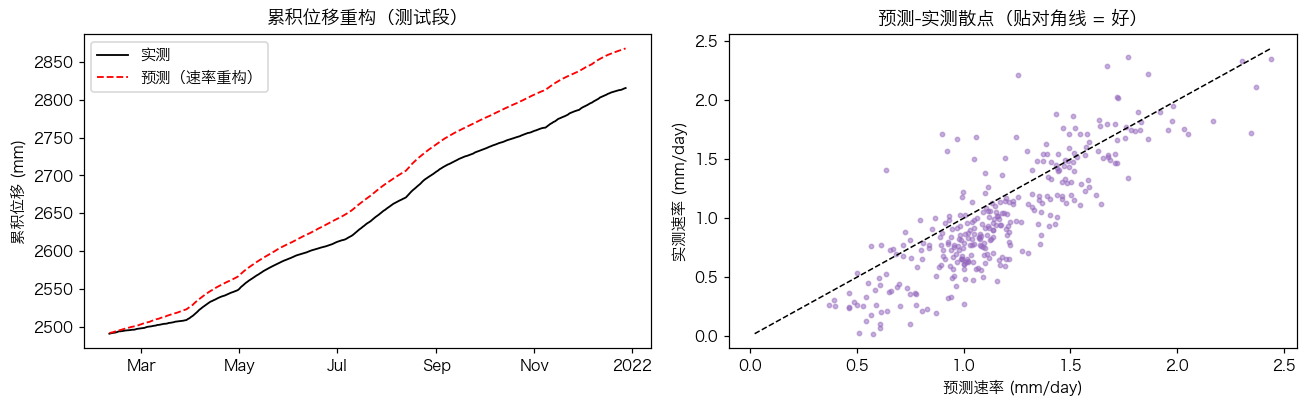

In [14]:
def rate_to_cum(rate_pred):
    """速率预测 → 累积位移重构：从测试段起点前一天的真实累积值出发累加。"""
    d0 = day_te[0]
    return tab["disp"][d0 - 1] + np.cumsum(np.asarray(rate_pred).ravel())


def cum_true_test():
    return tab["disp"][day_te]

cum_true_te = cum_true_test()
cum_pred0 = rate_to_cum(pred0)
report("XGBoost(默认)·累积重构", cum_true_te, cum_pred0, record=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.plot(tab["dates"][tab["m_te"]], cum_true_te, "k-", lw=1.2, label="实测")
ax.plot(tab["dates"][tab["m_te"]], cum_pred0, "r--", lw=1.2, label="预测（速率重构）")
ax.set_title("累积位移重构（测试段）"); ax.set_ylabel("累积位移 (mm)")
ax.legend(); fix_date_axis(ax)
ax = axes[1]
ax.scatter(pred0, yte, s=8, alpha=.5, color="tab:purple")
lim = [min(yte.min(), pred0.min()), max(yte.max(), pred0.max())]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("预测速率 (mm/day)"); ax.set_ylabel("实测速率 (mm/day)")
ax.set_title("预测-实测散点（贴对角线 = 好）")
plt.tight_layout(); plt.show()

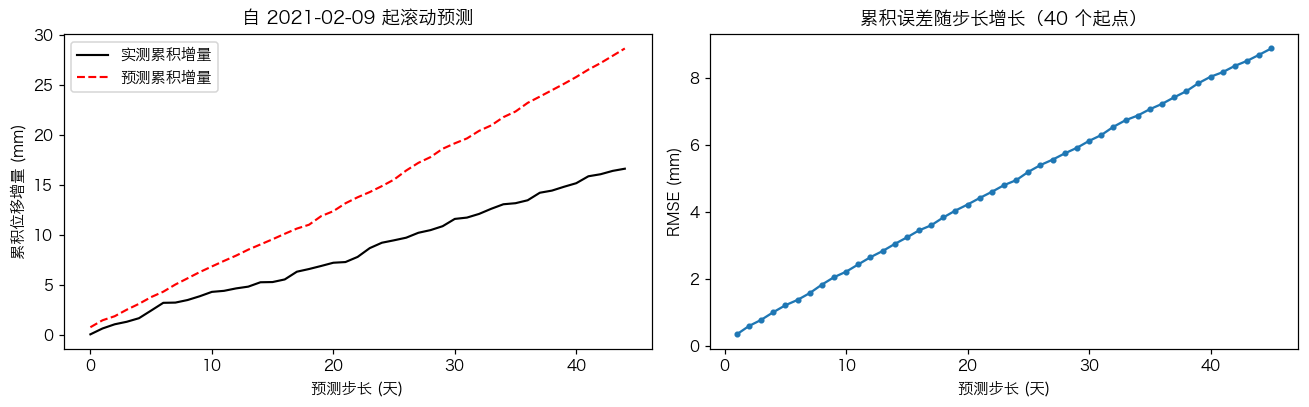

递归预测 RMSE：步长 1 = 0.34 mm，步长 30 = 6.11 mm，步长 45 = 8.87 mm


In [15]:
RAW_COLS = ["date", "rainfall_mm", "reservoir_m", "temp_c", "disp_mm"]

def recursive_forecast(predict_fn, origin_day, n_steps, tail=90):
    """滚动多步：预测速率回填自回归特征，位移用预测值累积。
    假设未来降雨/水位/温度有预报（用合成真值代替，与 ③ §7 同一假设）。"""
    W = df_raw.iloc[max(0, origin_day + 1 - tail):origin_day + 1].copy()   # 已知到 origin_day（含）
    rates = []
    for k in range(1, n_steps + 1):
        feat = add_features(W).iloc[-1]
        yhat = float(predict_fn(feat[FEATURE_COLS].to_numpy("float64")[None, :]))
        rates.append(yhat)
        nxt = df_raw.iloc[[origin_day + k]][RAW_COLS].copy()               # 未来日驱动（预报），取一行 DataFrame 保留 dtype
        nxt["disp_mm"] = W["disp_mm"].iloc[-1] + yhat                      # 位移用预测累积
        W = pd.concat([W, nxt], ignore_index=True)
    return np.array(rates)

def wrap_df(fn):
    def f(x):
        return float(fn(pd.DataFrame(x, columns=FEATURE_COLS))[0])
    return f

N_STEPS = 45
origin0 = int(day_te[0])
rate_rec0 = recursive_forecast(wrap_df(xgb0.predict), origin0, N_STEPS)
truth0 = tab["disp"][origin0:origin0 + N_STEPS] - tab["disp"][origin0 - 1]
cum_rec0 = tab["disp"][origin0 - 1] + np.cumsum(rate_rec0)

n_origins, sq_err = 0, np.zeros(N_STEPS)
for o in day_te[:-N_STEPS:7]:
    r_o = recursive_forecast(wrap_df(xgb0.predict), int(o), N_STEPS)
    sq_err += (np.cumsum(r_o) - (tab["disp"][o:o + N_STEPS] - tab["disp"][o - 1])) ** 2
    n_origins += 1
rmse_curve = np.sqrt(sq_err / n_origins)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(truth0, "k-", lw=1.4, label="实测累积增量")
axes[0].plot(cum_rec0 - tab["disp"][origin0 - 1], "r--", lw=1.4, label="预测累积增量")
axes[0].set_xlabel("预测步长 (天)"); axes[0].set_ylabel("累积位移增量 (mm)")
axes[0].set_title(f"自 {pd.Timestamp(tab['dates'][tab['m_te']][0]).date()} 起滚动预测")
axes[0].legend()
axes[1].plot(range(1, N_STEPS + 1), rmse_curve, "o-", ms=3)
axes[1].set_xlabel("预测步长 (天)"); axes[1].set_ylabel("RMSE (mm)")
axes[1].set_title(f"累积误差随步长增长（{n_origins} 个起点）")
plt.tight_layout(); plt.show()
print(f"递归预测 RMSE：步长 1 = {rmse_curve[0]:.2f} mm，步长 30 = {rmse_curve[29]:.2f} mm，步长 45 = {rmse_curve[-1]:.2f} mm")

## 7. 调参（随机搜索 + 早停）

树模型的超参分两拨：
- **复杂度**：`max_depth`（交互阶数：深度 3 ≈ 三阶交互）、`min_child_weight`、`gamma`——压过拟合；
- **随机性/正则**：`subsample`、`colsample_bytree`、`reg_lambda`——降方差、去特征共谋；
- `eta` 与树数联动：小 eta 多棵树更稳，配合早停自动定轮数。

随机搜索（12 组，val 早停评分，test 不参与）：

In [16]:
space_rng = np.random.default_rng(1)
SPACE = dict(max_depth=[3, 4, 5, 6], eta=[0.03, 0.05, 0.1, 0.2],
             subsample=[0.6, 0.8, 1.0], colsample_bytree=[0.6, 0.8, 1.0],
             min_child_weight=[1, 5, 10, 20], reg_lambda=[0.5, 1, 5, 10],
             gamma=[0, 0.5, 1])
N_TRIAL = 12

def fit_xgb(cfg, n_estimators=2000, register_as=None):
    model = XGBRegressor(n_estimators=n_estimators, learning_rate=cfg["eta"],
                         max_depth=cfg["max_depth"], min_child_weight=cfg["min_child_weight"],
                         subsample=cfg["subsample"], colsample_bytree=cfg["colsample_bytree"],
                         reg_lambda=cfg["reg_lambda"], gamma=cfg["gamma"],
                         tree_method="hist", random_state=SEED, eval_metric="rmse",
                         early_stopping_rounds=50)
    model.fit(Xtr_df, ytr, eval_set=[(Xva_df, yva)], verbose=False)
    if register_as:
        register(register_as, yte, model.predict(Xte_df))
    return model

t0 = time.time()
rows = []
for k in range(N_TRIAL):
    cfg = {p: space_rng.choice(v).item() for p, v in SPACE.items()}
    mdl = fit_xgb(cfg)
    val_rmse = math.sqrt(mean_squared_error(yva, mdl.predict(Xva_df)))
    rows.append({**cfg, "val_RMSE": val_rmse, "best_iter": mdl.best_iteration})
    print(f"trial {k:2d} | depth={cfg['max_depth']} eta={cfg['eta']} mcw={cfg['min_child_weight']} "
          f"sub={cfg['subsample']} col={cfg['colsample_bytree']} λ={cfg['reg_lambda']} γ={cfg['gamma']} "
          f"| val RMSE = {val_rmse:.4f} | 早停 iter = {mdl.best_iteration}  (累计 {time.time() - t0:.0f}s)")

search_df = pd.DataFrame(rows).sort_values("val_RMSE").reset_index(drop=True)
print("\n验证集 Top-5：")
search_df.head()

trial  0 | depth=4 eta=0.1 mcw=1 sub=1.0 col=1.0 λ=0.5 γ=1.0 | val RMSE = 0.2980 | 早停 iter = 25  (累计 0s)


trial  1 | depth=6 eta=0.03 mcw=5 sub=0.6 col=1.0 λ=1.0 γ=1.0 | val RMSE = 0.2961 | 早停 iter = 319  (累计 0s)
trial  2 | depth=4 eta=0.05 mcw=1 sub=0.8 col=0.8 λ=0.5 γ=1.0 | val RMSE = 0.2973 | 早停 iter = 109  (累计 1s)


trial  3 | depth=6 eta=0.2 mcw=5 sub=0.8 col=1.0 λ=1.0 γ=1.0 | val RMSE = 0.3120 | 早停 iter = 109  (累计 1s)


trial  4 | depth=3 eta=0.05 mcw=20 sub=0.6 col=0.8 λ=0.5 γ=0.5 | val RMSE = 0.2880 | 早停 iter = 118  (累计 1s)
trial  5 | depth=4 eta=0.2 mcw=5 sub=0.6 col=0.8 λ=0.5 γ=1.0 | val RMSE = 0.3023 | 早停 iter = 18  (累计 1s)


trial  6 | depth=3 eta=0.05 mcw=1 sub=0.8 col=0.8 λ=10.0 γ=1.0 | val RMSE = 0.2866 | 早停 iter = 281  (累计 1s)


trial  7 | depth=6 eta=0.03 mcw=10 sub=1.0 col=0.6 λ=10.0 γ=0.0 | val RMSE = 0.3041 | 早停 iter = 190  (累计 2s)


trial  8 | depth=5 eta=0.03 mcw=5 sub=0.6 col=1.0 λ=5.0 γ=0.0 | val RMSE = 0.2979 | 早停 iter = 132  (累计 2s)
trial  9 | depth=3 eta=0.05 mcw=20 sub=0.8 col=0.8 λ=1.0 γ=0.5 | val RMSE = 0.2894 | 早停 iter = 89  (累计 3s)


trial 10 | depth=6 eta=0.2 mcw=10 sub=0.8 col=0.6 λ=5.0 γ=1.0 | val RMSE = 0.2928 | 早停 iter = 109  (累计 3s)


trial 11 | depth=4 eta=0.05 mcw=10 sub=0.6 col=0.8 λ=10.0 γ=1.0 | val RMSE = 0.2861 | 早停 iter = 294  (累计 3s)

验证集 Top-5：


,max_depth,eta,subsample,colsample_bytree,min_child_weight,reg_lambda,gamma,val_RMSE,best_iter
0,4,0.05,0.6,0.8,10,10.0,1.0,0.286119,294
1,3,0.05,0.8,0.8,1,10.0,1.0,0.286638,281
2,3,0.05,0.6,0.8,20,0.5,0.5,0.288027,118
3,3,0.05,0.8,0.8,20,1.0,0.5,0.289384,89
4,6,0.20,0.8,0.6,10,5.0,1.0,0.292820,109


In [17]:
best_cfg = {p: (int(search_df.iloc[0][p]) if p == "max_depth" else float(search_df.iloc[0][p]))
            for p in SPACE}
print("最优配置:", best_cfg)
final_model = fit_xgb(best_cfg, register_as="XGBoost(调参后)")
print(f"早停 best_iteration = {final_model.best_iteration}")
pred_te = final_model.predict(Xte_df)
report("XGBoost(调参后)·累积重构", cum_true_te, rate_to_cum(pred_te), record=False)
pd.DataFrame(RESULTS).drop_duplicates(subset="模型", keep="last").round(4)

最优配置: {'max_depth': 4, 'eta': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 10.0, 'reg_lambda': 10.0, 'gamma': 1.0}


早停 best_iteration = 294
[XGBoost(调参后)·累积重构] RMSE=30.61 | MAE=27.54 | MAPE_pct=1.023 | R2=0.9115 | NSE=0.9115 | 最大误差=47.07


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,persistence(明日=今日),0.3559,0.2592,36.7185,0.4632,0.4632,1.6640
1,线性回归(同特征),0.2732,0.2004,23.8388,0.6838,0.6838,1.1483
2,岭回归(α=1),0.2708,0.1960,23.4184,0.6893,0.6893,1.1806
3,"从零GBM(200棵,depth3)",0.3643,0.2922,55.8882,0.4378,0.4378,0.9967
4,XGBoost(默认),0.3083,0.2513,45.2322,0.5971,0.5971,0.9603
5,XGBoost(调参后),0.2947,0.2390,43.2639,0.6320,0.6320,1.0113


### 7.2 gain 特征重要性：先看一眼，但别信它当归因

`gain` = 该特征在所有分裂中带来的平均目标下降——衡量"**训练时被用得多深**"，
不是"对预测的贡献"，更不是因果：高度相关的特征会互相"抢功劳"，被用得少的特征也可能一旦缺失就灾难。
严谨归因交给 §8 的 SHAP。

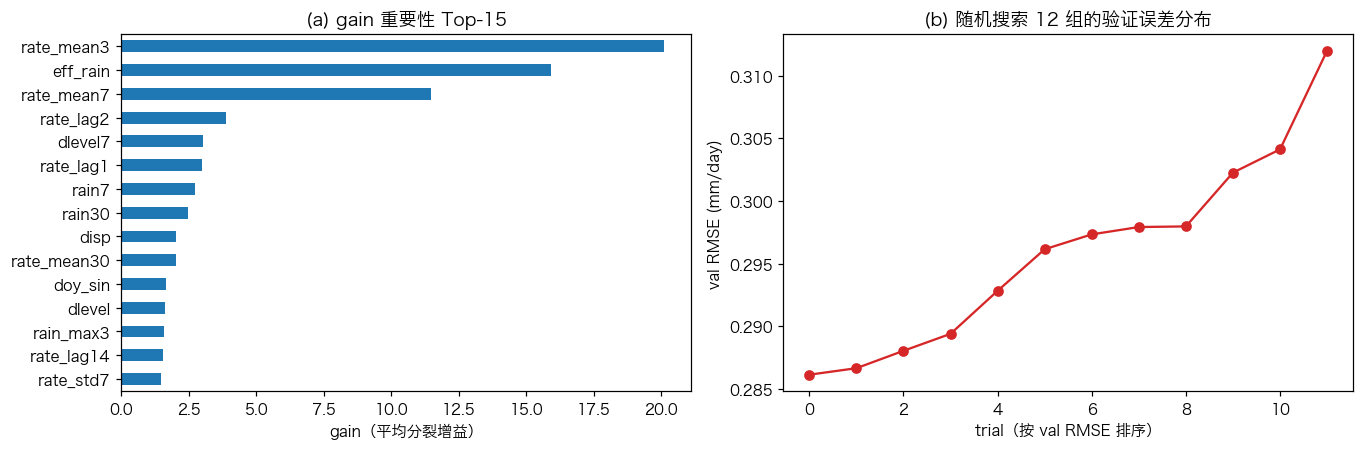

gain Top-5： ['rate_mean3', 'eff_rain', 'rate_mean7', 'rate_lag2', 'dlevel7']


In [18]:
gain_imp = final_model.get_booster().get_score(importance_type="gain")
gain_s = pd.Series({c: gain_imp.get(c, 0.0) for c in FEATURE_COLS}).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
gain_s.tail(15).plot.barh(ax=ax, color="tab:blue")
ax.set_xlabel("gain（平均分裂增益）"); ax.set_title("(a) gain 重要性 Top-15")

ax = axes[1]
ax.plot(search_df["val_RMSE"], "o-", color="tab:red")
ax.set_xlabel("trial（按 val RMSE 排序）"); ax.set_ylabel("val RMSE (mm/day)")
ax.set_title("(b) 随机搜索 12 组的验证误差分布")
plt.tight_layout(); plt.show()

print("gain Top-5：", list(gain_s.sort_values(ascending=False).head(5).index))

## 8. SHAP 可解释性：把每次预测精确分解成特征的贡献

### 8.1 原理：Shapley 值（合作博弈论 → 特征归因）

把"一次预测"看作 $M$ 个特征的合作成果，Shapley 值按**所有特征子集上的平均边际贡献**分摊：

$$\phi_i = \sum_{S \subseteq M \setminus \{i\}} \frac{|S|!\,(M-|S|-1)!}{M!}\big[v(S \cup \{i\}) - v(S)\big]$$

它天然满足三条公理，正好是工程归因要的性质：
- **加和性（有效性）**：$\sum_i \phi_i + \phi_{base} = $ 预测值——贡献分解**不重不漏**（§8.2 用它做一致性检查）；
- **一致性**：特征在模型中的贡献变大，其 $\phi_i$ 不会变小——重要性排序可信；
- **缺失替代（dummy）**：无贡献的特征 $\phi_i = 0$。

树模型的精确 TreeSHAP 是多项式算法（Lundberg et al. 2020）——**xgboost 内置 `pred_contribs` 就是它**，
不需要近似采样。SHAP 的"基线" $\phi_{base}$ = 训练集（DMatrix 背景分布）上的期望输出。

In [19]:
booster = final_model.get_booster()
dm_te = xgb.DMatrix(Xte_df, feature_names=FEATURE_COLS)
contribs = booster.predict(dm_te, pred_contribs=True)      # 精确 TreeSHAP（回归默认 exact）
phi = contribs[:, :-1]                                     # (n, F)：各特征 SHAP 值
base = float(contribs[0, -1])                              # 基线 = 期望输出
pred_shap = final_model.predict(Xte_df)

# —— SHAP 版的"梯度检查"：加和一致性（贡献分解 + 基线 = 预测）——
# 注：pred_contribs 走 float32 累加，几百棵树的舍入残差在 1e-3 量级，用相对误差判定
resid = np.abs(phi.astype("float64").sum(1) + base - pred_shap.astype("float64"))
rel_add = (resid / np.maximum(np.abs(pred_shap), 0.5)).max()
print(f"基线 φ_base = {base:.4f} mm/day")
print(f"加和一致性：max |Σφ + base − 预测| = {resid.max():.2e}（相对误差 {rel_add:.1e}）→",
      "✅ 通过（TreeSHAP 精确分解；残差为 float32 累加舍入量级）" if rel_add < 1e-2 else "❌")

基线 φ_base = 1.3837 mm/day
加和一致性：max |Σφ + base − 预测| = 5.25e-03（相对误差 6.6e-03）→ ✅ 通过（TreeSHAP 精确分解；残差为 float32 累加舍入量级）


### 8.2 全局重要性：bar 与 beeswarm

- **bar**：$\text{mean}|\phi_i|$ —— 平均影响幅度；
- **beeswarm**：每个点 = 一个样本；横轴 = SHAP 值，颜色 = 特征值高低 —— **同时读出"方向"**：
  （如 `eff_rain` 的点在高值时 SHAP 为正 → 有效降雨越大，预测速率越高）。

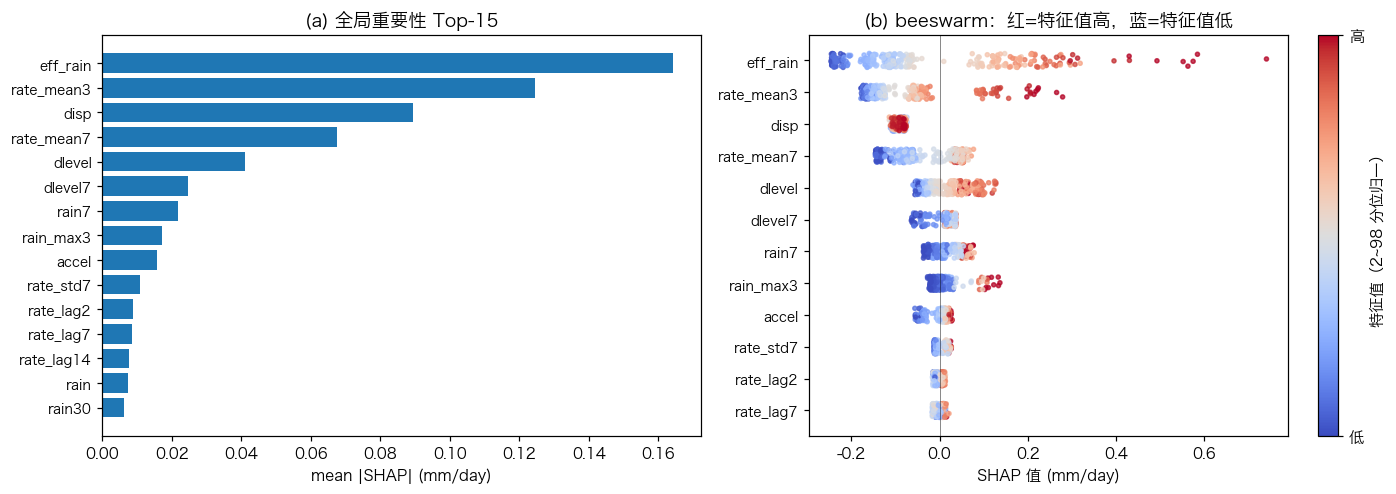

mean|SHAP| Top-5： [('eff_rain', 0.1642), ('rate_mean3', 0.1245), ('disp', 0.0895), ('rate_mean7', 0.0674), ('dlevel', 0.0411)]


In [20]:
mean_abs = np.abs(phi).mean(0)
order_g = np.argsort(mean_abs)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
top15 = order_g[:15][::-1]
ax.barh(range(15), mean_abs[top15], color="tab:blue")
ax.set_yticks(range(15), [FEATURE_COLS[j] for j in top15], fontsize=9)
ax.set_xlabel("mean |SHAP| (mm/day)"); ax.set_title("(a) 全局重要性 Top-15")

ax = axes[1]
TOPK = 12
rng_bw = np.random.default_rng(0)
for rank, j in enumerate(order_g[:TOPK]):
    v, xv = phi[:, j], Xte[:, j]
    lo, hi = np.quantile(xv, [0.02, 0.98])
    norm = np.clip((xv - lo) / (hi - lo + 1e-12), 0, 1)
    jit = rng_bw.uniform(-0.22, 0.22, len(v))
    ax.scatter(v, rank + jit, c=norm, cmap="coolwarm", s=7, alpha=.75, vmin=0, vmax=1)
ax.set_yticks(range(TOPK), [FEATURE_COLS[j] for j in order_g[:TOPK]], fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color="k", lw=.6, alpha=.5)
ax.set_xlabel("SHAP 值 (mm/day)"); ax.set_title("(b) beeswarm：红=特征值高，蓝=特征值低")
plt.colorbar(plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 1)), ax=ax,
             label="特征值（2~98 分位归一）", ticks=[0, 1],
             format=plt.FuncFormatter(lambda x, _: ["低", "高"][int(round(x))]))
plt.tight_layout(); plt.show()

print("mean|SHAP| Top-5：", [(FEATURE_COLS[j], round(float(mean_abs[j]), 4)) for j in order_g[:5]])

### 8.3 依赖图：响应形状与交互

dependence 图 = "某特征的取值 → 它的 SHAP 贡献"散点，颜色叠加另一个特征可暴露**交互**。
看两张：
1. `eff_rain`：响应是否递增/是否饱和（大降雨边际贡献趋平）？颜色（近 3 日最大雨强）分层说明"强度×滞后总量"交互；
2. `rate_lag1`：自回归项的形状——若在高速率端继续抬升，说明模型把"已经很快 → 明天更快"（加速惯性）学进了结构。

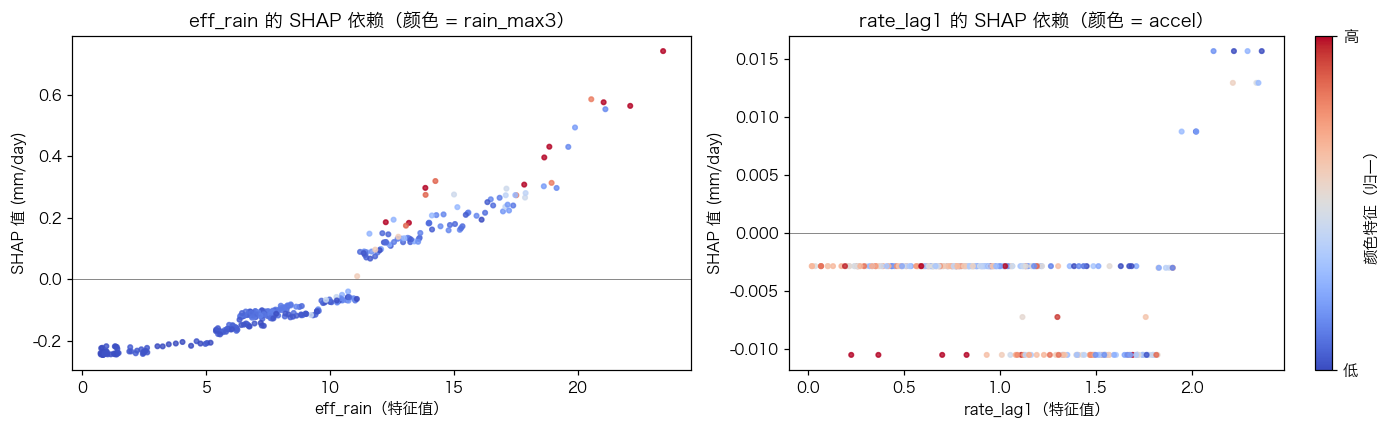

In [21]:
def dependence(ax, feat, color_feat, n_max=800):
    j, jc = FEATURE_COLS.index(feat), FEATURE_COLS.index(color_feat)
    idx = np.arange(len(phi))
    if len(idx) > n_max:
        idx = rng_bw.choice(idx, n_max, replace=False)
    lo, hi = np.quantile(Xte[idx, jc], [0.02, 0.98])
    norm = np.clip((Xte[idx, jc] - lo) / (hi - lo + 1e-12), 0, 1)
    sc = ax.scatter(Xte[idx, j], phi[idx, j], c=norm, cmap="coolwarm", s=9, alpha=.8, vmin=0, vmax=1)
    ax.axhline(0, color="k", lw=.6, alpha=.5)
    ax.set_xlabel(f"{feat}（特征值）"); ax.set_ylabel("SHAP 值 (mm/day)")
    ax.set_title(f"{feat} 的 SHAP 依赖（颜色 = {color_feat}）")
    return sc

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dependence(axes[0], "eff_rain", "rain_max3")
dependence(axes[1], "rate_lag1", "accel")
plt.colorbar(plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(0, 1)), ax=axes[1],
             label="颜色特征（归一）", ticks=[0, 1],
             format=plt.FuncFormatter(lambda x, _: ["低", "高"][int(round(x))]))
plt.tight_layout(); plt.show()

### 8.4 单点归因：一次"加速日"预测的瀑布图

L4 预警报告的最小单元：预警升级那天，模型为什么给出高速率预测？
取测试段**实测速率最高的一天**（加速日），把它的 SHAP 贡献画成瀑布：基线 → 各特征推/拉 → 最终预测。
每个特征的标注同时给出**特征取值**——"因为 eff_rain=XX（高于平常）把预测抬高了 YY mm/day"。

测试段最强加速日：2021-05-01 | 实测 2.36 mm/day | 预测 1.87 mm/day


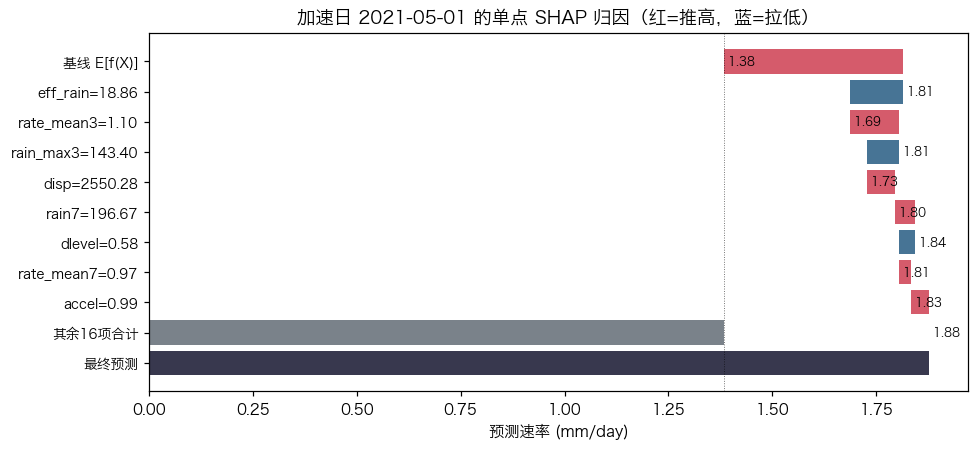

In [22]:
def waterfall(base, phi_row, x_row, names, max_display=8, title=""):
    order = np.argsort(-np.abs(phi_row))
    top, rest = order[:max_display], order[max_display:]
    vals = list(phi_row[top])
    labels = [f"{names[j]}={x_row[j]:.2f}" for j in top]
    if len(rest):
        vals.append(phi_row[rest].sum()); labels.append(f"其余{len(rest)}项合计")
    cum = [base]
    for v in vals:
        cum.append(cum[-1] + v)
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for i, v in enumerate(vals):
        lo, hi = min(cum[i], cum[i + 1]), max(cum[i], cum[i + 1])
        ax.barh(i, hi - lo, left=lo, color="#d1495b" if v > 0 else "#33658a", alpha=.9)
    ax.barh(len(vals), cum[0], color="#6c757d", alpha=.9)
    ax.barh(len(vals) + 1, cum[-1], color="#22223b", alpha=.9)
    labels = ["基线 E[f(X)]"] + labels + ["最终预测"]
    ax.set_yticks(range(len(vals) + 2), labels, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(base, color="k", lw=.6, ls=":", alpha=.6)
    for i, c in enumerate(cum):
        ax.text(c, i, f" {c:.2f}", va="center", fontsize=8)
    ax.set_xlabel("预测速率 (mm/day)"); ax.set_title(title)
    plt.tight_layout(); plt.show()

i_star = int(np.argmax(yte))
d_star = pd.Timestamp(tab["dates"][tab["m_te"]][i_star]).date()
print(f"测试段最强加速日：{d_star} | 实测 {yte[i_star]:.2f} mm/day | 预测 {pred_shap[i_star]:.2f} mm/day")
waterfall(base, phi[i_star], Xte[i_star], FEATURE_COLS,
          title=f"加速日 {d_star} 的单点 SHAP 归因（红=推高，蓝=拉低）")

### 8.5 加速期归因报告：预警升级时自动输出"主要驱动因子 Top-5"

把测试段按实测速率分成 **加速期**（前 20% 分位以上）与**平常期**，分别平均 |SHAP|：
若两份榜单不同（如加速期 `rain7`/`accel` 排名上升），就回答了"**这次加速主要因为什么**"——
这正是融合方案 L4 层的设计：每次预警升级自动跑 SHAP，输出 Top-5 驱动因子随预警单发出。

加速日（速率 ≥ 1.48 mm/day）占测试段 20%

加速期 Top-5 驱动因子（预警单随附）：
  1. eff_rain     mean|SHAP| = 0.2357 mm/day （全期排名 1）
  2. rate_mean3   mean|SHAP| = 0.1043 mm/day （全期排名 2）
  3. disp         mean|SHAP| = 0.0953 mm/day （全期排名 3）
  4. rate_mean7   mean|SHAP| = 0.0431 mm/day （全期排名 4）
  5. rain7        mean|SHAP| = 0.0406 mm/day （全期排名 7）


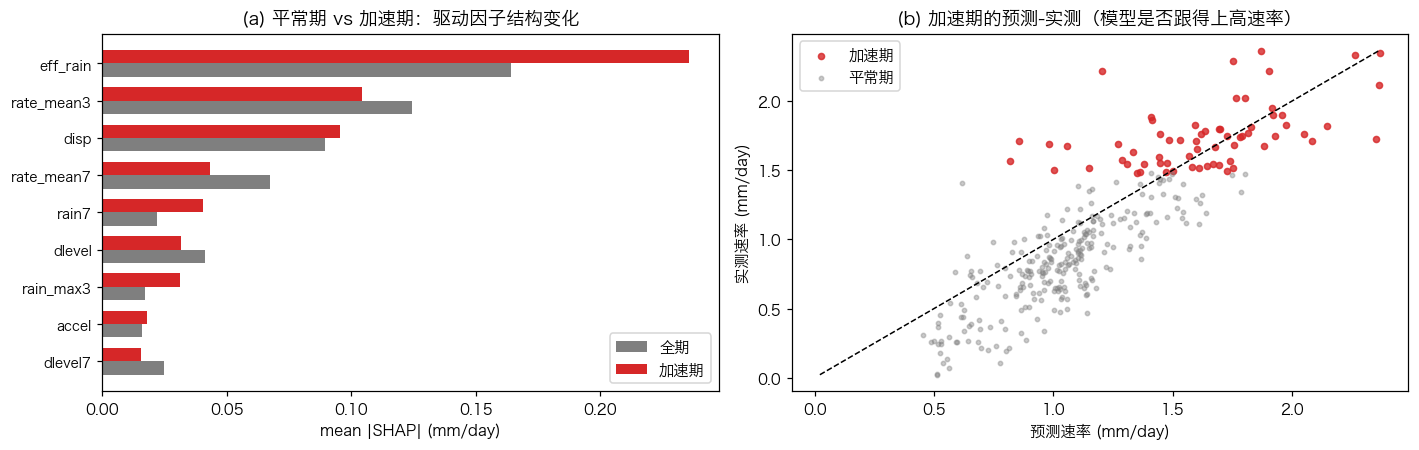

In [23]:
q80 = np.quantile(yte, 0.8)
m_acc = yte >= q80
imp_all, imp_acc = np.abs(phi).mean(0), np.abs(phi[m_acc]).mean(0)
o_all, o_acc = np.argsort(imp_all)[::-1], np.argsort(imp_acc)[::-1]

print(f"加速日（速率 ≥ {q80:.2f} mm/day）占测试段 {m_acc.mean():.0%}\n")
print("加速期 Top-5 驱动因子（预警单随附）：")
for k, j in enumerate(o_acc[:5]):
    print(f"  {k + 1}. {FEATURE_COLS[j]:12s} mean|SHAP| = {imp_acc[j]:.4f} mm/day "
          f"（全期排名 {int(np.where(o_all == j)[0][0]) + 1}）")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
sel = list(dict.fromkeys(list(o_acc[:8]) + list(o_all[:8])))
yy = np.arange(len(sel))
ax.barh(yy + 0.18, imp_all[sel], height=0.36, color="tab:gray", label="全期")
ax.barh(yy - 0.18, imp_acc[sel], height=0.36, color="tab:red", label="加速期")
ax.set_yticks(yy, [FEATURE_COLS[j] for j in sel], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel("mean |SHAP| (mm/day)"); ax.legend()
ax.set_title("(a) 平常期 vs 加速期：驱动因子结构变化")

ax = axes[1]
ax.scatter(pred_shap[m_acc], yte[m_acc], s=16, color="tab:red", alpha=.8, label="加速期")
ax.scatter(pred_shap[~m_acc], yte[~m_acc], s=8, color="tab:gray", alpha=.4, label="平常期")
lim = [min(yte.min(), pred_shap.min()), max(yte.max(), pred_shap.max())]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("预测速率 (mm/day)"); ax.set_ylabel("实测速率 (mm/day)")
ax.set_title("(b) 加速期的预测-实测（模型是否跟得上高速率）")
ax.legend()
plt.tight_layout(); plt.show()

In [24]:
# SHAP vs gain：两种重要性的排名是否一致？
try:
    from scipy.stats import spearmanr
    rho, _ = spearmanr(mean_abs, [gain_imp.get(c, 0.0) for c in FEATURE_COLS])
    print(f"mean|SHAP| 与 gain 的 Spearman 排名相关 = {rho:.3f}")
except Exception as e:
    print("scipy 不可用，跳过（原因）：", e)

# 特征交互：pred_interactions 的精确交互 SHAP（取平均 |φ_ij| 的 Top-8 对）
inter = booster.predict(dm_te, pred_interactions=True)     # (n, F+1, F+1) 精确交互 SHAP
ii = inter[:, :-1, :-1]                                    # 去掉基线行列
mean_inter = np.abs(ii).mean(0)
pairs = [(FEATURE_COLS[a], FEATURE_COLS[b], mean_inter[a, b])
         for a in range(len(FEATURE_COLS)) for b in range(a + 1, len(FEATURE_COLS))]
pairs.sort(key=lambda t: -t[2])
print("\n交互 Top-8（mean |φ_ij|, mm/day）：")
for a, b, v in pairs[:8]:
    print(f"  {a} × {b}: {v:.4f}")

mean|SHAP| 与 gain 的 Spearman 排名相关 = 0.715



交互 Top-8（mean |φ_ij|, mm/day）：
  rate_mean3 × eff_rain: 0.0148
  rate_mean7 × eff_rain: 0.0142
  disp × eff_rain: 0.0041
  rate_mean7 × disp: 0.0040
  rate_mean7 × dlevel7: 0.0040
  rate_mean3 × rate_mean7: 0.0037
  eff_rain × rain7: 0.0036
  eff_rain × dlevel: 0.0034


## 9. 改进方向

| 路线 | 手段 | 本 Notebook |
|---|---|---|
| 消融实验 | 逐特征族删除：自回归 / 降雨 / 库水位 / 仅环境 | §9.1 |
| **物理融合** | 降雨/骤降 → 速率的单调约束（`monotone_constraints`，树版物理先验） | §9.2 |
| 不确定性 | 分位数回归初探（正式的 Conformal 校准 → 算法⑤） | §9.3 |

[消融:−自回归族] RMSE=0.3174 mm/day | R2=0.5768


[消融:−降雨族] RMSE=0.2737 mm/day | R2=0.6826


[消融:−库水位族] RMSE=0.2986 mm/day | R2=0.6221
[消融:仅环境(无自回归/水平)] RMSE=0.4436 mm/day | R2=0.1729


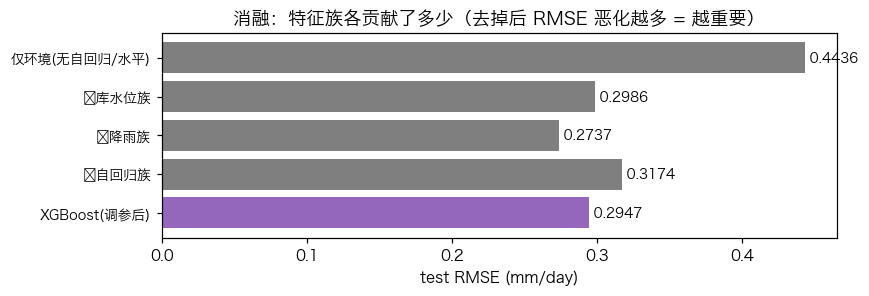

In [25]:
# ---------- 9.1 消融：哪个特征族在撑精度？ ----------
ABLATIONS = {"消融:−自回归族": ["自回归"], "消融:−降雨族": ["降雨"],
             "消融:−库水位族": ["库水位"], "消融:仅环境(无自回归/水平)": ["自回归", "水平"]}

abl_rows, abl_models = [], {}
for name, drop_groups in ABLATIONS.items():
    cols = [c for c in FEATURE_COLS if not any(c in GROUPS[g] for g in drop_groups)]
    t_ab = build_tabular(df_raw, feature_cols=cols)
    mdl = XGBRegressor(n_estimators=2000, learning_rate=best_cfg["eta"],
                       max_depth=best_cfg["max_depth"], min_child_weight=best_cfg["min_child_weight"],
                       subsample=best_cfg["subsample"], colsample_bytree=best_cfg["colsample_bytree"],
                       reg_lambda=best_cfg["reg_lambda"], gamma=best_cfg["gamma"],
                       tree_method="hist", random_state=SEED, eval_metric="rmse",
                       early_stopping_rounds=50)
    mdl.fit(t_ab["Xdf"].iloc[t_ab["m_tr"]], t_ab["y"][t_ab["m_tr"]],
            eval_set=[(t_ab["Xdf"].iloc[t_ab["m_va"]], t_ab["y"][t_ab["m_va"]])], verbose=False)
    r = regression_metrics(t_ab["y"][t_ab["m_te"]], mdl.predict(t_ab["Xdf"].iloc[t_ab["m_te"]]), name)
    RESULTS.append(r)          # 消融的测试段与主表相差 ±1 天，不进累积重构汇总（PRED_STORE）
    abl_models[name] = (t_ab, mdl)
    print(f"[{name}] RMSE={r['RMSE']:.4f} mm/day | R2={r['R2']:.4f}")

abl_names = ["XGBoost(调参后)"] + list(ABLATIONS)
vals_abl = [next(r for r in RESULTS if r["模型"] == n)["RMSE"] for n in abl_names]
plt.figure(figsize=(8, 2.8))
plt.barh(range(len(abl_names)), vals_abl, color=["tab:purple"] + ["tab:gray"] * (len(abl_names) - 1))
plt.yticks(range(len(abl_names)), [n.replace("消融:", "") for n in abl_names], fontsize=9)
plt.xlabel("test RMSE (mm/day)")
plt.title("消融：特征族各贡献了多少（去掉后 RMSE 恶化越多 = 越重要）")
for i, v in enumerate(vals_abl):
    plt.text(v, i, f" {v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

**消融解读**（如实报告，与 §8 的 SHAP 相互印证）：
- **−自回归**通常恶化最多——位移自身惯性是单步预测最大信息源（①③ 同理），这正是"递归多步误差累积"的根源（§6）；
- **仅环境**（无自回归/水平）的 RMSE 会显著变差，但它**不依赖位移观测**——传感器故障/空窗期时的"降级模型"仍有价值；
- 若去掉后持平甚至略降（本例 **−降雨族 0.2737 < 完整 0.2947**）——说明其短期信息已被自回归特征吸收，
  树模型为冗余特征多付了方差代价；但它的价值体现在**外推与归因**（§8.5 加速期榜单、§9.2 约束后的响应方向、
  递归多步时的物理锚点），这也是"精度指标之外要 SHAP"的原因。

### 9.2 物理融合：单调约束（树模型的"物理软约束"写法）

③ 的做法是把物理先验写成**损失项**（软约束，λ 扫描）；树模型有更结构化的等价物——**单调约束**：
限定预测对某特征的响应**方向**，不限形状。物理依据（与数据生成机制一致）：

- 有效降雨/降雨累计/雨强 ↑ → 速率不应下降：`+1`；干期越长 → 速率不应上升：`-1`；
- 库水位骤降幅度 ↑（`drawdown7` ↑、`dlevel` 更负）→ 速率不应下降：`+1` / `-1`；
- 温度、季节项、自回归项：`0`（交给数据）。

价值在**外推**：训练集没见过的超强降雨下，无约束树可能学出"雨太大反而塌"的非物理响应，
单调约束从结构上杜绝；代价是表达能力略受限——按 val 表现决定用不用（与 ③ 的 λ 扫描同一权衡逻辑）。

In [26]:
MONO = {c: 0 for c in FEATURE_COLS}
for c in ["rain", "eff_rain", "rain7", "rain30", "rain_max3"]:
    MONO[c] = +1
MONO["dry_days"] = -1
MONO["drawdown7"] = +1
MONO["dlevel"] = -1
MONO["dlevel7"] = -1
mc = tuple(MONO[c] for c in FEATURE_COLS)
print("单调约束（+1/-1/0）：" + ", ".join(f"{c}:{v}" for c, v in MONO.items() if v != 0))

mono_model = XGBRegressor(n_estimators=2000, learning_rate=best_cfg["eta"],
                          max_depth=best_cfg["max_depth"], min_child_weight=best_cfg["min_child_weight"],
                          subsample=best_cfg["subsample"], colsample_bytree=best_cfg["colsample_bytree"],
                          reg_lambda=best_cfg["reg_lambda"], gamma=best_cfg["gamma"],
                          monotone_constraints=mc,
                          tree_method="hist", random_state=SEED, eval_metric="rmse",
                          early_stopping_rounds=50)
mono_model.fit(Xtr_df, ytr, eval_set=[(Xva_df, yva)], verbose=False)
register("XGBoost+物理单调约束", yte, mono_model.predict(Xte_df))
print(f"早停 best_iteration = {mono_model.best_iteration}")

val_rmse_u = math.sqrt(mean_squared_error(yva, final_model.predict(Xva_df)))
val_rmse_m = math.sqrt(mean_squared_error(yva, mono_model.predict(Xva_df)))
print(f"val  RMSE：无约束 {val_rmse_u:.4f} | 单调约束 {val_rmse_m:.4f}")
print(f"test RMSE：无约束 {next(r['RMSE'] for r in RESULTS if r['模型'] == 'XGBoost(调参后)'):.4f} | "
      f"单调约束 {next(r['RMSE'] for r in RESULTS if r['模型'] == 'XGBoost+物理单调约束'):.4f}")

单调约束（+1/-1/0）：rain:1, eff_rain:1, rain7:1, rain30:1, rain_max3:1, dry_days:-1, dlevel:-1, dlevel7:-1, drawdown7:1


早停 best_iteration = 176
val  RMSE：无约束 0.2861 | 单调约束 0.2892
test RMSE：无约束 0.2947 | 单调约束 0.2965


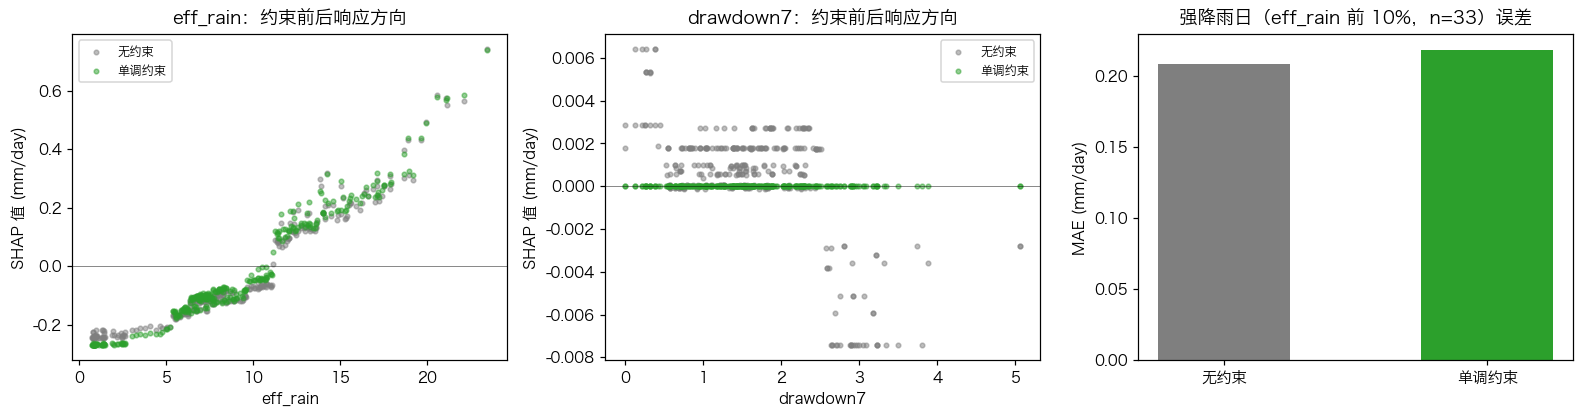

In [27]:
dm_te2 = xgb.DMatrix(Xte_df, feature_names=FEATURE_COLS)
phi_mono = mono_model.get_booster().predict(dm_te2, pred_contribs=True)[:, :-1]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
for ax, feat in zip(axes[:2], ["eff_rain", "drawdown7"]):
    j = FEATURE_COLS.index(feat)
    ax.scatter(Xte[:, j], phi[:, j], s=9, alpha=.5, color="tab:gray", label="无约束")
    ax.scatter(Xte[:, j], phi_mono[:, j], s=9, alpha=.5, color="tab:green", label="单调约束")
    ax.axhline(0, color="k", lw=.6, alpha=.5)
    ax.set_xlabel(feat); ax.set_ylabel("SHAP 值 (mm/day)")
    ax.set_title(f"{feat}：约束前后响应方向"); ax.legend(fontsize=8)

ax = axes[2]
hi_rain = Xte[:, FEATURE_COLS.index("eff_rain")] >= np.quantile(Xte[:, FEATURE_COLS.index("eff_rain")], 0.9)
mae_u = np.mean(np.abs(yte[hi_rain] - pred_te[hi_rain]))
mae_m = np.mean(np.abs(yte[hi_rain] - mono_model.predict(Xte_df)[hi_rain]))
ax.bar(["无约束", "单调约束"], [mae_u, mae_m], color=["tab:gray", "tab:green"], width=.5)
ax.set_ylabel("MAE (mm/day)")
ax.set_title(f"强降雨日（eff_rain 前 10%，n={hi_rain.sum()}）误差")
plt.tight_layout(); plt.show()

**单调约束解读**（如实报告）：若约束后 val/test RMSE 持平或略升、而强降雨日误差不变或改善——
就是"以极小精度代价买下物理可解释性与外推稳健性"，风险评价场景值得开；
两图应能看到约束后 SHAP 依赖不再出现非物理的负向段。真实工程上还可以把约束做成**敏感性清单**
（对 `level/temp` 等放开 vs 收紧各跑一遍，看 val 稳定性），与 ③ 的 λ 扫描同一模板。

### 9.3 不确定性初探：分位数回归（正式区间 → 算法⑤）

把平方损失换成 pinball 损失（`reg:quantileerror`），同框架训练 5%/95% 两个分位数模型 → 90% 预测区间。
树版 $(g,h)$：$g = \tau - \mathbb{1}\{y < \hat y\}$，$h = 1$——只换损失、不动框架（§4.1 说的"框架不变"）。
注意：分位数回归的**覆盖率没有保证**（尤其外推段），正式的风险区间用 ⑤ 的 Conformal 在本模型残差上做校准。

90% 分位数区间：PICP = 0.935（理想 ≈ 0.90）| 平均宽度 = 1.210 mm/day
区间宽度 与 |误差| 的相关 = 0.241（>0 说明区间在'该宽的地方更宽'，有区分度）


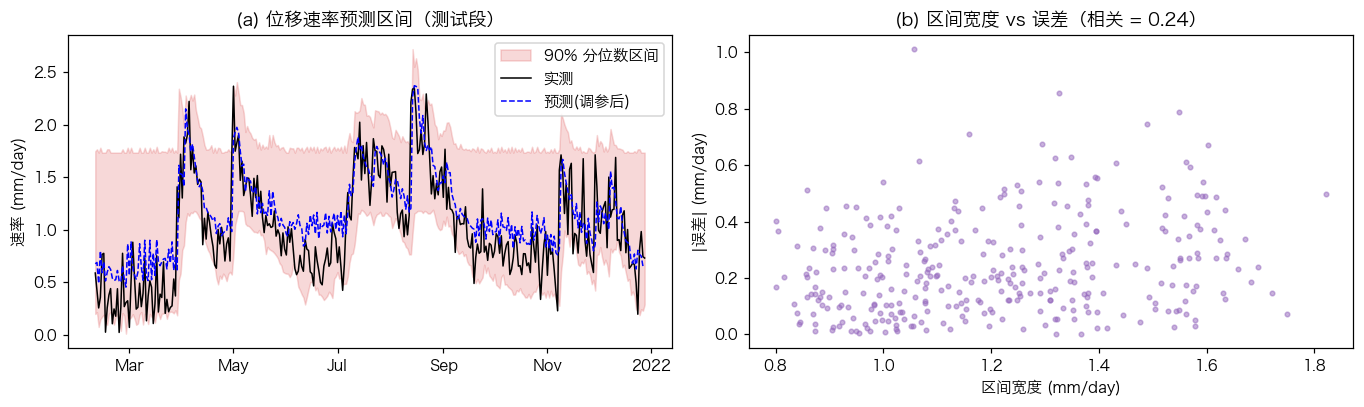

In [28]:
def fit_quantile(alpha, n_trees):
    qm = XGBRegressor(objective="reg:quantileerror", quantile_alpha=alpha,
                      n_estimators=n_trees, learning_rate=best_cfg["eta"],
                      max_depth=best_cfg["max_depth"], min_child_weight=best_cfg["min_child_weight"],
                      subsample=best_cfg["subsample"], colsample_bytree=best_cfg["colsample_bytree"],
                      reg_lambda=best_cfg["reg_lambda"], gamma=best_cfg["gamma"],
                      tree_method="hist", random_state=SEED)
    qm.fit(Xtr_df, ytr, verbose=False)
    return qm

n_q = max(int(final_model.best_iteration), 100)
q_lo, q_hi = fit_quantile(0.05, n_q).predict(Xte_df), fit_quantile(0.95, n_q).predict(Xte_df)
picp = np.mean((yte >= q_lo) & (yte <= q_hi))
width = q_hi - q_lo
corr = np.corrcoef(width, np.abs(yte - pred_te))[0, 1]
print(f"90% 分位数区间：PICP = {picp:.3f}（理想 ≈ 0.90）| 平均宽度 = {width.mean():.3f} mm/day")
print(f"区间宽度 与 |误差| 的相关 = {corr:.3f}（>0 说明区间在'该宽的地方更宽'，有区分度）")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax = axes[0]
dates_te = pd.to_datetime(tab["dates"][tab["m_te"]])
ax.fill_between(dates_te, q_lo, q_hi, color="tab:red", alpha=.18, label="90% 分位数区间")
ax.plot(dates_te, yte, "k-", lw=1, label="实测")
ax.plot(dates_te, pred_te, "b--", lw=1, label="预测(调参后)")
ax.set_title("(a) 位移速率预测区间（测试段）"); ax.set_ylabel("速率 (mm/day)")
ax.legend(); fix_date_axis(ax)
ax = axes[1]
ax.scatter(width, np.abs(yte - pred_te), s=9, alpha=.5, color="tab:purple")
ax.set_xlabel("区间宽度 (mm/day)"); ax.set_ylabel("|误差| (mm/day)")
ax.set_title(f"(b) 区间宽度 vs 误差（相关 = {corr:.2f}）")
plt.tight_layout(); plt.show()

## 10. 结果汇总与接入真实数据

### 10.1 全部实验汇总（test 集，速率空间 mm/day）

In [29]:
summary = pd.DataFrame(RESULTS).drop_duplicates(subset="模型", keep="last").reset_index(drop=True)
summary.to_csv("xgb_shap_results_summary.csv", index=False)
print("已保存 xgb_shap_results_summary.csv")
summary.round(4)

已保存 xgb_shap_results_summary.csv


,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,persistence(明日=今日),0.3559,0.2592,36.7185,0.4632,0.4632,1.6640
1,线性回归(同特征),0.2732,0.2004,23.8388,0.6838,0.6838,1.1483
2,岭回归(α=1),0.2708,0.1960,23.4184,0.6893,0.6893,1.1806
3,"从零GBM(200棵,depth3)",0.3643,0.2922,55.8882,0.4378,0.4378,0.9967
4,XGBoost(默认),0.3083,0.2513,45.2322,0.5971,0.5971,0.9603
5,XGBoost(调参后),0.2947,0.2390,43.2639,0.6320,0.6320,1.0113
6,消融:−自回归族,0.3174,0.2691,49.6761,0.5768,0.5768,0.9005
7,消融:−降雨族,0.2737,0.2115,36.8174,0.6826,0.6826,1.0356
8,消融:−库水位族,0.2986,0.2458,45.5892,0.6221,0.6221,0.9985
9,消融:仅环境(无自回归/水平),0.4436,0.3979,72.5631,0.1729,0.1729,0.9319


**累积重构口径**（应用视角，mm）：

In [30]:
cum_rows = []
for name, (yt_r, yp_r) in PRED_STORE.items():
    if name.endswith("·累积重构"):
        continue
    cum_rows.append(regression_metrics(cum_true_te, rate_to_cum(yp_r), name))
cum_summary = pd.DataFrame(cum_rows).round(3)
cum_summary.to_csv("xgb_shap_results_summary_cumulative.csv", index=False)
cum_summary

,模型,RMSE,MAE,MAPE_pct,R2,NSE,最大误差
0,persistence(明日=今日),1.081,0.964,0.036,1.000,1.000,2.325
1,线性回归(同特征),24.667,20.463,0.755,0.943,0.943,46.993
2,岭回归(α=1),23.466,19.458,0.717,0.948,0.948,44.644
3,"从零GBM(200棵,depth3)",43.066,39.295,1.462,0.825,0.825,64.982
4,XGBoost(默认),33.524,29.923,1.111,0.894,0.894,52.624
5,XGBoost(调参后),30.608,27.535,1.023,0.912,0.912,47.069
6,XGBoost+物理单调约束,30.836,27.653,1.027,0.910,0.910,48.815


**与 ①③ 的横向对比**（同一合成数据、同一划分比例，速率口径 test RMSE，各自实测）：

| 模型 | 速率 RMSE (mm/day) | 累积重构 RMSE (mm) | 备注 |
|---|---|---|---|
| ① LSTM（调参后） | 0.2570 | 13.38 | 30 天窗口递归网络 |
| ③ CNN-Transformer（调参后） | 0.2632 | 10.42 | 60 天窗口混合架构 |
| ④ XGBoost（调参后，本篇） | 见 §10.1 | 见累积表 | 24 个工程特征 + GBDT |

三类模型落在同一量级——单步预测的信息上限由数据本身（噪声底 $\sigma\approx0.15$）决定，
架构差异体现在**怎么用**：深度模型胜在端到端与长窗口外推，树模型胜在训练速度、特征可插拔、
**精确归因（SHAP）与结构化物理约束（单调性）**——后者正是 L4 风险预警层最需要的能力。
（④ 的特征表因 30 日滚动特征比 ①③ 晚 31 天开始，测试段不完全重合，对比仅供参考。）

### 10.2 接入真实数据 Checklist

1. ✅ **L2 融合层单点宽表** CSV 放入本目录（列：date, 融合位移/速率, 驱动量, InSAR 面域量）；
2. ✅ §3 `GROUPS` 增删特征族（如 `"InSAR": ["insar_vel", "coh_chg", "dist_edge"]`），保持**因果红线**：每行特征只用 ≤τ 的观测；
3. ✅ 先跑 §5 基线（persistence 必须被打败，否则特征/划分有泄漏或目标不可预报）；
4. ✅ §7 调参（随机搜索 + val 早停）→ §8 SHAP 检查特征合理性（如 `eff_rain` 依赖应单调非负——物理 sanity check）；
5. ✅ §9.1 消融论证特征族必要性 → §9.2 物理单调约束（真实边坡强烈建议开：强降雨外推的保险）；
6. ✅ 风险应用：§8.5 加速期 Top-5 归因随预警单发出（L4）；区间与超越概率接算法⑤（Conformal 校准）。

### 10.3 进阶路线（与 ⑤⑥⑦⑧ 衔接）

| 方向 | 做法 | 关键词 |
|---|---|---|
| 区间 | 在本模型残差上做 Conformal 校准 → 有限样本覆盖保证；InSAR-GNSS 分歧度作区间放大器 | 算法⑤ |
| 物理 | 约束升级：interaction constraints（限定降雨×滞后的交互白名单）、`reg:quantileerror` 全分位数集 | monotonic GBDT |
| 时空 | 每个测点一个 ④ 模型 + SHAP 汇总成"空间归因图"；或特征加入邻近测点速率（手工图特征） | per-point GBDT |
| 基础模型 | Chronos/TimesFM zero-shot 作为"无特征基线"与本篇对比（算法⑧） | zero-shot |

**常见坑速查**：随机打乱样本 ❌｜rolling/滞后特征包含目标时刻 ❌（一律 ≤τ）｜线性基线不标准化 ❌｜把 gain 重要性当 SHAP/归因用 ❌｜递归多步时外生特征用真值假装有完美预报（报告时要声明假设）❌｜早停挂 test ❌｜小样本开大 depth+小 min_child_weight ❌｜分位数区间当"保证覆盖率"用 ❌（那是 ⑤ 的活）